### Execution Topic 0.1: Google Colab Environment Setup

**What it does:** installs the only packages this training needs. `sentence-transformers`, `networkx`, `pandas`, `numpy`, `scikit-learn` and `matplotlib` already ship with Colab; `igraph` + `leidenalg` provide the **Leiden** community-detection algorithm from slide 24.

**Observe:** the cell finishes quietly (`-q`). Run it once per fresh runtime.

In [ ]:
# ---------------------------------------------------------
# Install packages (quiet mode). Already-installed packages are skipped.
# igraph + leidenalg = the reference implementation of the Leiden algorithm.
# ---------------------------------------------------------
!pip -q install sentence-transformers networkx igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.1 MB/s eta 0:00:00


### Execution Topic 0.2: Imports, Reproducibility and Plot Helpers

**What it does:** imports every library used later, fixes random seeds so the whole class sees identical outputs, and defines two small drawing helpers used for graph visuals.

**Observe:** the printed library versions — useful if a participant's output ever differs.

In [ ]:
# ---------------------------------------------------------
# Step 1: Imports used across the whole notebook
# ---------------------------------------------------------
import re, math, time, random, textwrap, warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg
import sentence_transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Step 2: Reproducibility — same seed => same layouts, same communities
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 200)

# ---------------------------------------------------------
# Step 3: Plot helpers for graphs
# ---------------------------------------------------------
TYPE_COLORS = {
    "Customer": "#f4a261", "Order": "#e76f51", "Machine": "#2a9d8f", "Failure": "#e63946",
    "Part": "#8ab17d", "Supplier": "#6c9bd2", "Location": "#a8dadc", "Event": "#b388eb",
    "Chipmaker": "#2a9d8f", "Owner": "#6c9bd2", "Exchange": "#f4a261", "Node": "#9ecae1",
}
PALETTE = plt.cm.tab10.colors

def line_layout(nodes, gap=2.2):
    """Place nodes left-to-right: ideal for a causal chain."""
    return {n: (i * gap, 0) for i, n in enumerate(nodes)}

def component_layout(G):
    """Lay out each connected component on its own (Kamada-Kawai), side by side."""
    U = G.to_undirected()
    pos, x_offset = {}, 0.0
    for comp in sorted(nx.connected_components(U), key=len, reverse=True):
        sub = U.subgraph(comp)
        p = nx.kamada_kawai_layout(sub) if len(comp) > 2 else {n: (i * 0.5, 0.0) for i, n in enumerate(comp)}
        scale = math.sqrt(len(comp)) / 2
        xs = [x for x, _ in p.values()]
        for n, (x, y) in p.items():
            pos[n] = ((x - min(xs)) * scale + x_offset, y * scale)
        x_offset += (max(xs) - min(xs)) * scale + 0.8
    return pos

def draw_graph(G, title="", pos=None, node_color="#9ecae1", edge_label_attr=None,
               width_attr=None, ax=None, node_size=1800, font_size=8, figsize=(11, 6)):
    """Draw a (Di)Graph with optional edge labels and weight-scaled edge widths."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)
    pos = pos or nx.spring_layout(G, seed=SEED, k=1.4)
    widths = [1.2 + 1.8 * (G.edges[e].get(width_attr, 1) - 1) for e in G.edges] if width_attr else 1.4
    labels = {n: textwrap.fill(str(n), 14) for n in G.nodes()}          # wrap long entity names
    nx.draw_networkx(G, pos, ax=ax, labels=labels, node_color=node_color, node_size=node_size, font_size=font_size,
                     width=widths, edge_color="#555555", arrows=G.is_directed(), arrowsize=16)
    if edge_label_attr:
        labels = nx.get_edge_attributes(G, edge_label_attr)
        labels = {k: (", ".join(sorted(v)) if isinstance(v, (set, list, tuple)) else v) for k, v in labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=7, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
        plt.show()

print("numpy", np.__version__, "| pandas", pd.__version__, "| networkx", nx.__version__)
print("sentence-transformers", sentence_transformers.__version__, "| leidenalg", leidenalg.__version__, "| igraph", ig.__version__)
print("Setup complete. Seed =", SEED)

numpy 2.1.3 | pandas 2.2.3 | networkx 3.6.1
sentence-transformers 5.7.0 | leidenalg 0.12.0 | igraph 1.0.0
Setup complete. Seed = 42


## Part 1 — Recap: Vector RAG (slides 3–4)

Slide 4 shows two halves:
* **Offline indexing:** Data / Documents → Data Chunks → Embedder → Vector Database
* **Online querying:** User Query → Embedder → Vector Database → Top-k Relevant Chunks → Appended Prompt → LLM → Generated Response

We now execute each box, using the enterprise archive from the BMW case study.

### Execution Topic 1.1: Data / Documents → Data Chunks

**What it does:** creates the Q3 enterprise archive as four **documents** (one per department silo) and splits them into **chunks** with a simple word-budget chunker.

**Why it matters:** chunks are the unit that gets embedded and retrieved — the first arrow in slide 4.

**Observe:** at a 60-word budget the 4 documents become a few long chunks; at a 17-word budget (the longest log entry) every entry becomes its own chunk — 17 chunks. Chunks `C01`–`C04` are exactly the four chunks **A–D** from the case study (slide 8).

In [ ]:
# ---------------------------------------------------------
# Step 1: The Q3 enterprise archive — one record per log entry.
# C01–C04 are chunks A–D from the BMW case study (slide 8).
# The other records are the rest of the quarter's paperwork.
# ---------------------------------------------------------
archive_records = [
    # (record_id, silo, date, text)
    ("C01", "Sales CRM",            "2026-08-28", "BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver."),
    ("C02", "Factory Floor Logs",   "2026-08-02", "BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2)."),
    ("C03", "Maintenance Tickets",  "2026-08-10", "Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals."),
    ("C04", "Procurement Invoices", "2026-08-12", "Emergency seals delayed at port (customs hold)."),
    ("C05", "Procurement Invoices", "2026-08-06", "SealTech GmbH shipped the emergency seals via Port of Hamburg (Aug 6)."),
    ("C06", "Maintenance Tickets",  "2026-09-03", "Press Cell 4 halted again (Sep 3): hydraulic oil leak; repair requires emergency seals."),
    ("C07", "Factory Floor Logs",   "2026-09-01", "BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1)."),
    ("C08", "Sales CRM",            "2026-09-18", "BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18)."),
    ("C09", "Sales CRM",            "2026-07-15", "Nordwerk Motors account: 2-week delivery delay for Order #415 (Jul 15) after Weld Line 2 idle time."),
    ("C10", "Factory Floor Logs",   "2026-07-02", "Nordwerk Motors Order #415 frame welding scheduled on Weld Line 2 (Jul 2)."),
    ("C11", "Procurement Invoices", "2026-07-05", "Nordstahl AG shipped steel coils via Port of Hamburg (Jul 5)."),
    ("C12", "Procurement Invoices", "2026-07-08", "Steel coils delayed at Port of Hamburg (port congestion) (Jul 8)."),
    ("C13", "Factory Floor Logs",   "2026-07-10", "Weld Line 2 idle (Jul 10): waiting for steel coils."),
    ("C14", "Factory Floor Logs",   "2026-08-20", "Alpen Trucks Order #431 cab painting scheduled on Paint Line 1 (Aug 20)."),
    ("C15", "Maintenance Tickets",  "2026-08-22", "Paint Line 1 halted (Aug 22): paint contamination defect traced to primer batch PB-77."),
    ("C16", "Procurement Invoices", "2026-08-18", "ChemCoat supplied primer batch PB-77 (Aug 18)."),
    ("C17", "Sales CRM",            "2026-08-30", "Alpen Trucks account: 1-week delivery delay for Order #431 (Aug 30) due to paint rework."),
]
archive_df = pd.DataFrame(archive_records, columns=["record_id", "silo", "date", "text"])

# ---------------------------------------------------------
# Step 2: Group records into DOCUMENTS — one document per department silo
# ---------------------------------------------------------
documents = {silo: list(zip(g["record_id"], g["text"])) for silo, g in archive_df.groupby("silo", sort=False)}
print(f"Documents (department silos): {len(documents)}")
for silo, recs in documents.items():
    print(f"  {silo:<22} {len(recs)} records, {sum(len(t.split()) for _, t in recs):>3} words")

# ---------------------------------------------------------
# Step 3: A simple chunker — pack consecutive records until the word budget is hit
# ---------------------------------------------------------
def chunk_document(records, max_words):
    chunks, ids, texts = [], [], []
    for rid, text in records:
        if ids and sum(len(t.split()) for t in texts) + len(text.split()) > max_words:
            chunks.append(("+".join(ids), " ".join(texts)))
            ids, texts = [], []
        ids.append(rid)
        texts.append(text)
    if ids:
        chunks.append(("+".join(ids), " ".join(texts)))
    return chunks

def chunk_corpus(max_words):
    rows = []
    for silo, recs in documents.items():
        for chunk_id, text in chunk_document(recs, max_words):
            rows.append({"chunk_id": chunk_id, "silo": silo, "text": text, "n_words": len(text.split())})
    return pd.DataFrame(rows)

longest_entry = int(archive_df["text"].str.split().str.len().max())
print(f"\nChunks at 60-word budget: {len(chunk_corpus(60))}")
print(f"Chunks at {longest_entry}-word budget: {len(chunk_corpus(longest_entry))}  "
      f"<- we use this: {longest_entry} words = longest log entry, so every entry is its own chunk")

# ---------------------------------------------------------
# Step 4: Final chunk table used for the rest of the notebook
# ---------------------------------------------------------
chunks_df = (chunk_corpus(longest_entry)
             .merge(archive_df[["record_id", "date"]], left_on="chunk_id", right_on="record_id")
             .drop(columns="record_id").sort_values("chunk_id").reset_index(drop=True))
chunks_df["pdf_label"] = chunks_df["chunk_id"].map({"C01": "A", "C02": "B", "C03": "C", "C04": "D"}).fillna("")
chunks_df = chunks_df[["chunk_id", "pdf_label", "silo", "date", "n_words", "text"]]
display(chunks_df)

Documents (department silos): 4
  Sales CRM              4 records,  64 words
  Factory Floor Logs     5 records,  60 words
  Maintenance Tickets    3 records,  42 words
  Procurement Invoices   5 records,  48 words

Chunks at 60-word budget: 5
Chunks at 17-word budget: 17  <- we use this: 17 words = longest log entry, so every entry is its own chunk


,chunk_id,pdf_label,silo,date,n_words,text
0,C01,A,Sales CRM,2026-08-28,17,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
1,C02,B,Factory Floor Logs,2026-08-02,12,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
2,C03,C,Maintenance Tickets,2026-08-10,14,Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals.
3,C04,D,Procurement Invoices,2026-08-12,7,Emergency seals delayed at port (customs hold).
4,C05,,Procurement Invoices,2026-08-06,12,SealTech GmbH shipped the emergency seals via Port of Hamburg (Aug 6).
5,C06,,Maintenance Tickets,2026-09-03,14,Press Cell 4 halted again (Sep 3): hydraulic oil leak; repair requires emergency seals.
6,C07,,Factory Floor Logs,2026-09-01,12,BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).
7,C08,,Sales CRM,2026-09-18,15,BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).
8,C09,,Sales CRM,2026-07-15,17,Nordwerk Motors account: 2-week delivery delay for Order #415 (Jul 15) after Weld Line 2 idle time.
9,C10,,Factory Floor Logs,2026-07-02,13,Nordwerk Motors Order #415 frame welding scheduled on Weld Line 2 (Jul 2).


### Execution Topic 1.2: The Embedder — Chunks → Vector Embeddings

**What it does:** passes every chunk through a sentence-transformer (`all-MiniLM-L6-v2`), turning text into a dense vector — the "Embedder → High Dimensional Space → Vector Embedding" boxes of slide 4.

**Observe:** 17 vectors, each with 384 dimensions, and the first numbers of one vector. Semantically similar text lands close together in this 384-D space.

In [ ]:
# ---------------------------------------------------------
# Step 1: Load a lightweight open-source embedding model (runs on CPU)
# ---------------------------------------------------------
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# ---------------------------------------------------------
# Step 2: Embed every chunk -> this matrix IS our "vector database"
# ---------------------------------------------------------
chunk_embeddings = embed_model.encode(chunks_df["text"].tolist(), convert_to_numpy=True)

print(f"Number of chunks embedded : {chunk_embeddings.shape[0]}")
print(f"Embedding dimensions      : {chunk_embeddings.shape[1]}")
print(f"Sample vector (chunk C01, first 8 of 384 values):\n{np.round(chunk_embeddings[0][:8], 4)}")
print(f"Vector length (L2 norm) of C01: {np.linalg.norm(chunk_embeddings[0]):.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of chunks embedded : 17
Embedding dimensions      : 384
Sample vector (chunk C01, first 8 of 384 values):
[-0.0014  0.0251  0.0052  0.005  -0.0666  0.0275 -0.0116 -0.0305]
Vector length (L2 norm) of C01: 1.0000


### Execution Topic 1.3: Cosine Similarity — the "Sim." Score

**Mathematical intuition**

$$\text{cosine similarity}(A,B) = \frac{A \cdot B}{\lVert A\rVert\,\lVert B\rVert}$$

Where:
* $A$ = query vector, $B$ = chunk vector
* $A \cdot B = \sum_i A_i B_i$ = dot product
* $\lVert A\rVert = \sqrt{\sum_i A_i^2}$ = magnitude of $A$ (same for $B$)

The result lies in $[-1, 1]$: **1** = same direction, **0** = unrelated (orthogonal).

**What it does:** calculates the formula by hand with NumPy, first on tiny 3-D vectors, then on real 384-D embeddings, and verifies against scikit-learn.

**Observe:** manual and library results match to ~1e-7.

In [ ]:
# ---------------------------------------------------------
# Step 1: The formula, written by hand
# ---------------------------------------------------------
def cosine_manual(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# ---------------------------------------------------------
# Step 2: Toy 3-D vectors to build intuition
# ---------------------------------------------------------
A = np.array([1.0, 2.0, 3.0])
B = np.array([2.0, 4.0, 6.0])     # same direction as A (just longer)
C = np.array([-3.0, 0.0, 1.0])    # perpendicular to A
print("Toy vectors")
print(f"  A.B = {np.dot(A, B):.1f}, ||A|| = {np.linalg.norm(A):.4f}, ||B|| = {np.linalg.norm(B):.4f}")
print(f"  cos(A, B) = {cosine_manual(A, B):.4f}   <- same direction")
print(f"  cos(A, C) = {cosine_manual(A, C):.4f}   <- orthogonal / unrelated")

# ---------------------------------------------------------
# Step 3: Real embeddings — a query vs. chunk C02
# ---------------------------------------------------------
query = "Which press cell was BMW Order #402 scheduled on?"
q_vec = embed_model.encode([query])[0]
c02_vec = chunk_embeddings[chunks_df.index[chunks_df["chunk_id"] == "C02"][0]]

manual = cosine_manual(q_vec, c02_vec)
library = cosine_similarity([q_vec], [c02_vec])[0, 0]
print(f"\nQuery : {query}")
print(f"Chunk : {chunks_df.loc[chunks_df.chunk_id == 'C02', 'text'].iloc[0]}")
print(f"Manual cosine similarity  : {manual:.6f}")
print(f"Library cosine similarity : {library:.6f}")
print(f"Difference                : {abs(manual - library):.8f}")

Toy vectors
  A.B = 28.0, ||A|| = 3.7417, ||B|| = 7.4833
  cos(A, B) = 1.0000   <- same direction
  cos(A, C) = 0.0000   <- orthogonal / unrelated

Query : Which press cell was BMW Order #402 scheduled on?
Chunk : BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
Manual cosine similarity  : 0.819465
Library cosine similarity : 0.819464
Difference                : 0.00000012


### Execution Topic 1.4: Online Querying — Top-k Relevant Chunks

**Mathematical intuition:** score every chunk $c$ against the query $q$ and keep the $k$ best:

$$\text{Top-}k(q) = \underset{S \subseteq \text{chunks},\ |S| = k}{\arg\max} \sum_{c \in S} \cos(q, c)$$

**What it does:** implements the vector-database lookup — embed the query, score all chunks, sort, keep top-k.

**Observe:** for a simple *lookup* question, the right chunk (`C02`) is rank 1. Vector RAG works well here — remember this for Part 11.

In [ ]:
# ---------------------------------------------------------
# Reusable vector search over any (dataframe, embedding-matrix) store
# ---------------------------------------------------------
def vector_search(query, k=3, store_df=None, store_embeddings=None):
    store_df = chunks_df if store_df is None else store_df
    store_embeddings = chunk_embeddings if store_embeddings is None else store_embeddings
    q = embed_model.encode([query])
    scores = cosine_similarity(q, store_embeddings)[0]           # one score per chunk
    ranked = store_df.assign(score=np.round(scores.astype(float), 3)).sort_values("score", ascending=False)
    top = ranked.head(k).reset_index(drop=True)
    top.insert(0, "rank", range(1, len(top) + 1))
    return top

lookup_query = "Which press cell was BMW Order #402 scheduled on?"
top_k = vector_search(lookup_query, k=3)
print(f"Query: {lookup_query}\n")
display(top_k[["rank", "chunk_id", "silo", "score", "text"]])
print(f"Top-1 chunk: {top_k.loc[0, 'chunk_id']} -> the answer ('Press Cell 4') is in it.")

Query: Which press cell was BMW Order #402 scheduled on?



,rank,chunk_id,silo,score,text
0,1,C02,Factory Floor Logs,0.819,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
1,2,C07,Factory Floor Logs,0.770,BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).
2,3,C08,Sales CRM,0.690,BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).


Top-1 chunk: C02 -> the answer ('Press Cell 4') is in it.


### Execution Topic 1.5: Appended Prompt → LLM

**What it does:** builds the **appended prompt** — retrieved chunks + the user question — which is what the LLM would receive in slide 4.

**Observe:** the LLM only ever sees the retrieved context. We stop at the prompt (no API key needed); any LLM would answer "Press Cell 4" from this context and cite `C02`.

In [ ]:
# ---------------------------------------------------------
# Build the prompt the LLM receives: instructions + retrieved context + question
# ---------------------------------------------------------
def build_prompt(question, context_df):
    context = "\n".join(f"[{r.chunk_id} | {r.silo}] {r.text}" for r in context_df.itertuples())
    return ("Answer the question using ONLY the context below. Cite chunk ids.\n\n"
            f"Context:\n{context}\n\nQuestion: {question}\nAnswer:")

appended_prompt = build_prompt(lookup_query, top_k)
print(appended_prompt)
print(f"\nPrompt length: {len(appended_prompt.split())} words  |  chunks in context: {len(top_k)}")

Answer the question using ONLY the context below. Cite chunk ids.

Context:
[C02 | Factory Floor Logs] BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
[C07 | Factory Floor Logs] BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).
[C08 | Sales CRM] BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).

Question: Which press cell was BMW Order #402 scheduled on?
Answer:

Prompt length: 76 words  |  chunks in context: 3


## Part 2 — What RAG Solved (slide 5)

Four wins: **knowledge cutoff**, **private / domain data**, **hallucination**, **provenance**. Each gets a short execution below.

### Execution Topic 2.1: Knowledge Cutoff and Private Data — Update Documents, Not the Model

**What it does:** builds an index "frozen" on 31 Aug, asks about September's BMW Order #447, then adds only the new September records to the index.

**Why it matters:** the LLM is never retrained — we embed a handful of new chunks and the answer becomes available. This is also private data no public LLM was trained on.

**Observe:** before the update Order #447's delay is not retrievable; after embedding only the new chunks, `C08` ranks first.

In [ ]:
question = "Was BMW Order #447 delayed, and why?"
cutoff = "2026-08-31"

# ---------------------------------------------------------
# Step 1: An index built at the "knowledge cutoff" (records up to 31 Aug)
# ---------------------------------------------------------
old_df = chunks_df[chunks_df["date"] <= cutoff].reset_index(drop=True)
old_emb = embed_model.encode(old_df["text"].tolist())
before = vector_search(question, k=2, store_df=old_df, store_embeddings=old_emb)
print(f"Question: {question}\n\nBEFORE update ({len(old_df)} chunks indexed, cutoff {cutoff}):")
display(before[["rank", "chunk_id", "date", "score", "text"]])

# ---------------------------------------------------------
# Step 2: New September documents arrive -> embed ONLY those, append to the index
# ---------------------------------------------------------
new_df = chunks_df[chunks_df["date"] > cutoff].reset_index(drop=True)
new_emb = embed_model.encode(new_df["text"].tolist())
updated_df = pd.concat([old_df, new_df], ignore_index=True)
updated_emb = np.vstack([old_emb, new_emb])

after = vector_search(question, k=2, store_df=updated_df, store_embeddings=updated_emb)
print(f"AFTER update (+{len(new_df)} new chunks embedded, LLM retrainings needed: 0):")
display(after[["rank", "chunk_id", "date", "score", "text"]])
print("Order #447 delay retrievable before update:", before["text"].str.contains("#447 after").any())
print("Order #447 delay retrievable after update :", after["text"].str.contains("#447 after").any())

Question: Was BMW Order #447 delayed, and why?

BEFORE update (14 chunks indexed, cutoff 2026-08-31):


,rank,chunk_id,date,score,text
0,1,C01,2026-08-28,0.695,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
1,2,C02,2026-08-02,0.574,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).


AFTER update (+3 new chunks embedded, LLM retrainings needed: 0):


,rank,chunk_id,date,score,text
0,1,C08,2026-09-18,0.722,BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).
1,2,C01,2026-08-28,0.695,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.


Order #447 delay retrievable before update: False
Order #447 delay retrievable after update : True


### Execution Topic 2.2: Provenance — Cite Which Documents Support the Answer

**What it does:** attaches source metadata (chunk id, silo, date) to every retrieved chunk, so the answer can cite its evidence.

**Observe:** a citation list a reviewer can check line by line.

In [ ]:
# ---------------------------------------------------------
# Retrieval returns metadata, not just text -> citations come for free
# ---------------------------------------------------------
provenance_query = "When was Order #402 scheduled on Press Cell 4?"
hits = vector_search(provenance_query, k=2)

print(f"Question: {provenance_query}\n")
print("Evidence the LLM would be given, with citations:")
for r in hits.itertuples():
    print(f"  [{r.chunk_id} | {r.silo} | {r.date} | sim={r.score}]  {r.text}")
print("\nCited sources:", ", ".join(f"{r.chunk_id} ({r.silo})" for r in hits.itertuples()))

Question: When was Order #402 scheduled on Press Cell 4?

Evidence the LLM would be given, with citations:
  [C02 | Factory Floor Logs | 2026-08-02 | sim=0.614]  BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
  [C07 | Factory Floor Logs | 2026-09-01 | sim=0.582]  BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).

Cited sources: C02 (Factory Floor Logs), C07 (Factory Floor Logs)


### Execution Topic 2.3: Hallucination — Inspect the Source Chunks

**What it does:** takes candidate answer statements and, for each one, finds the most similar source chunk. A statement with a strong matching chunk is *grounded*; one without is a candidate hallucination.

**Why it matters:** RAG reduces made-up facts because every claim can be checked against an inspectable chunk.

**Observe:** the invented "labour strike" statement has weaker support and — more importantly — its best "evidence" chunk says nothing about a strike. The chunk is there for a human to inspect.

In [ ]:
# ---------------------------------------------------------
# Step 1: Candidate answer statements (the last one is invented)
# ---------------------------------------------------------
statements = [
    "Order #402 was scheduled on Press Cell 4.",
    "Press Cell 4 stopped because of a hydraulic pump seal blowout.",
    "BMW asked for a penalty waiver.",
    "The chassis order was delayed by a labour strike at the paint shop.",   # not in the archive
]

# ---------------------------------------------------------
# Step 2: For each statement, find the best supporting chunk
# ---------------------------------------------------------
SUPPORT_THRESHOLD = 0.60   # simple teaching threshold, tune per corpus
stmt_emb = embed_model.encode(statements)
support = cosine_similarity(stmt_emb, chunk_embeddings)

rows = []
for i, s in enumerate(statements):
    j = int(np.argmax(support[i]))
    rows.append({"statement": s, "best_chunk": chunks_df.loc[j, "chunk_id"],
                 "support": round(float(support[i, j]), 3),
                 "grounded?": "YES" if support[i, j] >= SUPPORT_THRESHOLD else "CHECK - weak support",
                 "evidence_text": chunks_df.loc[j, "text"]})
display(pd.DataFrame(rows))

,statement,best_chunk,support,grounded?,evidence_text
0,Order #402 was scheduled on Press Cell 4.,C02,0.611,YES,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
1,Press Cell 4 stopped because of a hydraulic pump seal blowout.,C03,0.864,YES,Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals.
2,BMW asked for a penalty waiver.,C01,0.693,YES,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
3,The chassis order was delayed by a labour strike at the paint shop.,C17,0.511,CHECK - weak support,Alpen Trucks account: 1-week delivery delay for Order #431 (Aug 30) due to paint rework.


**Is RAG the perfect solution?** (slide 5) — Let's test it on the question an executive actually asked.

## Part 3 — Case Study: The Delayed BMW Delivery (slides 6–7)

### Execution Topic 3.1: The Scenario — Four Silos, One Executive Question

**What it does:** shows the indexed archive by silo and isolates the four records A–D that together explain the delay.

**Observe:** every fact exists in the archive, but each lives in a **different department** — the root of the problem in Part 4.

In [ ]:
executive_question = "Why was the custom BMW chassis order delayed by three weeks in August?"

# ---------------------------------------------------------
# Step 1: What the archive holds, per silo
# ---------------------------------------------------------
print("Enterprise archive (indexed documents across four silos):")
display(chunks_df.groupby("silo").agg(records=("chunk_id", "count"), chunk_ids=("chunk_id", ", ".join)))

# ---------------------------------------------------------
# Step 2: The four facts that explain the BMW delay
# ---------------------------------------------------------
case_df = chunks_df[chunks_df["pdf_label"] != ""].reset_index(drop=True)
case_embeddings = chunk_embeddings[chunks_df.index[chunks_df["pdf_label"] != ""]]
print(f"Executive question: \"{executive_question}\"\n")
display(case_df[["pdf_label", "chunk_id", "silo", "date", "text"]])
print("Each of the four facts lives in a different silo:", case_df["silo"].nunique() == 4)

Enterprise archive (indexed documents across four silos):


,records,chunk_ids
silo,,
Factory Floor Logs,5,"C02, C07, C10, C13, C14"
Maintenance Tickets,3,"C03, C06, C15"
Procurement Invoices,5,"C04, C05, C11, C12, C16"
Sales CRM,4,"C01, C08, C09, C17"


Executive question: "Why was the custom BMW chassis order delayed by three weeks in August?"



,pdf_label,chunk_id,silo,date,text
0,A,C01,Sales CRM,2026-08-28,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
1,B,C02,Factory Floor Logs,2026-08-02,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
2,C,C03,Maintenance Tickets,2026-08-10,Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals.
3,D,C04,Procurement Invoices,2026-08-12,Emergency seals delayed at port (customs hold).


Each of the four facts lives in a different silo: True


## Part 4 — Why Standard Vector RAG Fails (slides 8–10)

### Execution Topic 4.1: Similarity of Each Chunk to the Executive Question

**What it does:** reproduces the slide-8 table with real numbers — cosine similarity of chunks A–D to the question, plus which **query terms** literally appear in each chunk (slide 8 highlights them in blue).

**Observe:** A (Sales) scores highest — it shares *BMW, order, delay, week* with the question — and B is close behind because it mentions *BMW order chassis*. C, the actual root cause, scores **lowest of all**: it shares no query term.

In [ ]:
# ---------------------------------------------------------
# Step 1: Query-term overlap (light normalisation: lower-case, strip -s/-ed/-ing)
# ---------------------------------------------------------
STOPWORDS = {"why", "was", "the", "by", "in", "of", "a", "on", "for", "at", "to", "and", "what", "were", "is"}
def normalise(word):
    for suffix in ("ing", "ed", "es", "s"):
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[: -len(suffix)]
    return word
def terms(text):
    return {normalise(w) for w in re.findall(r"[a-z0-9#]+", text.lower()) if w not in STOPWORDS}

query_terms = terms(executive_question)
print("Query terms:", sorted(query_terms))

# ---------------------------------------------------------
# Step 2: Cosine similarity of the question vs. chunks A-D
# ---------------------------------------------------------
q_vec = embed_model.encode([executive_question])
sims = cosine_similarity(q_vec, case_embeddings)[0]

def sim_band(s):   # teaching bands mirroring the High / Med / Low column of slide 8
    return "High" if s >= 0.50 else ("Med" if s >= 0.35 else "Low")

table = case_df[["pdf_label", "silo", "text"]].copy()
table["cosine"] = np.round(sims, 3)
table["sim_band"] = [sim_band(s) for s in sims]
table["query_terms_present"] = [", ".join(sorted(query_terms & terms(t))) or "-" for t in table["text"]]
table["rank"] = table["cosine"].rank(ascending=False).astype(int)
display(table.sort_values("rank")[["rank", "pdf_label", "silo", "cosine", "sim_band", "query_terms_present", "text"]])

Query terms: ['august', 'bmw', 'chassi', 'custom', 'delay', 'order', 'three', 'week']


,rank,pdf_label,silo,cosine,sim_band,query_terms_present,text
0,1,A,Sales CRM,0.633,High,"bmw, delay, order, week",BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
1,2,B,Factory Floor Logs,0.625,High,"bmw, chassi, order",BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
3,3,D,Procurement Invoices,0.280,Low,"custom, delay",Emergency seals delayed at port (customs hold).
2,4,C,Maintenance Tickets,0.139,Low,-,Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals.


### Execution Topic 4.2: Run Vector Retrieval — The Delay Is Confirmed, the Cause Is Missing

**What it does:** runs top-k retrieval over chunks A–D for k = 1 and k = 2, then checks the retrieved context against the four links of the causal chain.

**Observe:** with k = 1 only **Chunk A** comes back (slide 8's result). Even k = 2 adds the factory schedule but still not the **pump failure** or the **customs hold**. The assembled answer matches slide 9: *"The underlying cause is not mentioned."*

In [ ]:
# ---------------------------------------------------------
# Step 1: The four links an analyst needs to explain the delay
# ---------------------------------------------------------
CAUSAL_LINKS = {
    "1. Delay confirmed (symptom)":              "delivery delay",
    "2. Order routed to Press Cell 4":           "press cell 4",
    "3. Root cause: hydraulic pump seal failure": "pump seal",
    "4. Blocker: emergency seals in customs":    "customs hold",
}
def link_coverage(texts):
    joined = " ".join(texts).lower()
    return {link: ("FOUND" if kw in joined else "missing") for link, kw in CAUSAL_LINKS.items()}

# ---------------------------------------------------------
# Step 2: Retrieve with k=1 and k=2 over the four case chunks
# ---------------------------------------------------------
for k in (1, 2):
    hits = vector_search(executive_question, k=k, store_df=case_df, store_embeddings=case_embeddings)
    print(f"=== Vector RAG, top-{k} ===")
    for r in hits.itertuples():
        print(f"  retrieved chunk {r.pdf_label} ({r.silo}, sim={r.score}): {r.text}")
    for link, status in link_coverage(hits["text"]).items():
        print(f"    {'[x]' if status == 'FOUND' else '[ ]'} {link:<45} {status}")
    print()

# ---------------------------------------------------------
# Step 3: What an answer built only from the top-1 chunk can say
# ---------------------------------------------------------
top1 = vector_search(executive_question, k=1, store_df=case_df, store_embeddings=case_embeddings)
coverage = link_coverage(top1["text"])
answer = "BMW Order #402 was delayed by three weeks, and the client requested a penalty waiver."
if coverage["3. Root cause: hydraulic pump seal failure"] == "missing":
    answer += " The underlying cause is not mentioned."
print("Vector RAG answer:", answer)

=== Vector RAG, top-1 ===
  retrieved chunk A (Sales CRM, sim=0.633): BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
    [x] 1. Delay confirmed (symptom)                  FOUND
    [ ] 2. Order routed to Press Cell 4               missing
    [ ] 3. Root cause: hydraulic pump seal failure    missing
    [ ] 4. Blocker: emergency seals in customs        missing

=== Vector RAG, top-2 ===
  retrieved chunk A (Sales CRM, sim=0.633): BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
  retrieved chunk B (Factory Floor Logs, sim=0.625): BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
    [x] 1. Delay confirmed (symptom)                  FOUND
    [x] 2. Order routed to Press Cell 4               FOUND
    [ ] 3. Root cause: hydraulic pump seal failure    missing
    [ ] 4. Blocker: emergency seals in customs        missing

Vector RAG answer: BMW Orde

### Execution Topic 4.3: At Archive Scale, the Cause Sinks Further Down

**What it does:** asks the same question against the **full 17-chunk archive**.

**Why it matters:** other orders' delay notes share *more* words with the question than the maintenance and procurement records do, so the true cause (C03, C04) is outranked by noise.

**Observe:** the rank of C03 and C04 — you would need a large k (and a lot of irrelevant context) to reach them.

In [ ]:
# ---------------------------------------------------------
# Rank ALL archive chunks for the executive question
# ---------------------------------------------------------
full_ranking = vector_search(executive_question, k=len(chunks_df))
display(full_ranking[["rank", "chunk_id", "pdf_label", "silo", "score", "text"]].head(8))

for cid, role in [("C01", "symptom (Sales)"), ("C03", "root cause (Maintenance)"), ("C04", "blocker (Procurement)")]:
    rank = int(full_ranking.loc[full_ranking.chunk_id == cid, "rank"].iloc[0])
    print(f"{cid} {role:<26} -> rank {rank:>2} of {len(full_ranking)}")
needed_k = int(full_ranking.loc[full_ranking.chunk_id.isin(["C03", "C04"]), "rank"].max())
print(f"\nTo include the full cause, top-k would need k >= {needed_k} "
      f"({needed_k - 2} of those chunks are about other orders or unrelated events).")

,rank,chunk_id,pdf_label,silo,score,text
0,1,C01,A,Sales CRM,0.633,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
1,2,C02,B,Factory Floor Logs,0.625,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
2,3,C08,,Sales CRM,0.608,BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).
3,4,C07,,Factory Floor Logs,0.478,BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).
4,5,C17,,Sales CRM,0.463,Alpen Trucks account: 1-week delivery delay for Order #431 (Aug 30) due to paint rework.
5,6,C09,,Sales CRM,0.454,Nordwerk Motors account: 2-week delivery delay for Order #415 (Jul 15) after Weld Line 2 idle time.
6,7,C12,,Procurement Invoices,0.352,Steel coils delayed at Port of Hamburg (port congestion) (Jul 8).
7,8,C10,,Factory Floor Logs,0.295,Nordwerk Motors Order #415 frame welding scheduled on Weld Line 2 (Jul 2).


C01 symptom (Sales)            -> rank  1 of 17
C03 root cause (Maintenance)   -> rank 16 of 17
C04 blocker (Procurement)      -> rank 10 of 17

To include the full cause, top-k would need k >= 16 (14 of those chunks are about other orders or unrelated events).


### Execution Topic 4.4: The Multi-Hop Breakdown — Four Islands, Severed Links

**What it does:** marks which key entities each chunk mentions, then shows which entities **bridge** each pair of chunks.

**Why it matters (slides 9–10):** the facts are isolated islands. The only way from A to D is A → B → C → D, hopping through shared entities. Cosine search scores each chunk **independently** and never follows these hops.

**Observe:** A and D share nothing, yet D explains A.

Entity mentions per chunk:


,BMW,Order #402,Press Cell 4,Pump seal,Emergency seals,Customs hold
A (Sales CRM),X,X,,,,
B (Factory Floor Logs),X,X,X,,,
C (Maintenance Tickets),,,X,X,X,
D (Procurement Invoices),,,,,X,X


Chunk A <-> Chunk B share: ['BMW', 'Order #402']
Chunk B <-> Chunk C share: ['Press Cell 4']
Chunk C <-> Chunk D share: ['Emergency seals']
Chunk A <-> Chunk D share: NOTHING


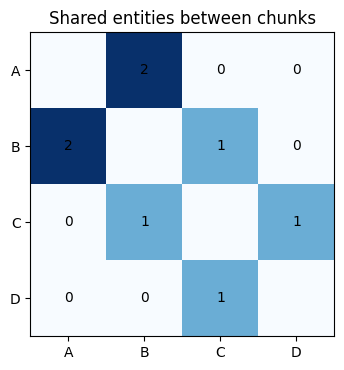

In [ ]:
# ---------------------------------------------------------
# Step 1: Which key entities does each chunk mention?
# ---------------------------------------------------------
KEY_ENTITIES = {"BMW": "bmw", "Order #402": "order #402", "Press Cell 4": "press cell 4",
                "Pump seal": "pump seal", "Emergency seals": "emergency seals", "Customs hold": "customs hold"}
presence = pd.DataFrame(
    {label: [("X" if kw in t.lower() else "") for t in case_df["text"]] for label, kw in KEY_ENTITIES.items()},
    index=[f"{l} ({s})" for l, s in zip(case_df["pdf_label"], case_df["silo"])])
print("Entity mentions per chunk:")
display(presence)

# ---------------------------------------------------------
# Step 2: Shared entities between every pair of chunks = possible "hops"
# ---------------------------------------------------------
mentions = {l: {e for e, kw in KEY_ENTITIES.items() if kw in t.lower()} for l, t in zip(case_df["pdf_label"], case_df["text"])}
labels = list(mentions)
shared = pd.DataFrame([[len(mentions[a] & mentions[b]) if a != b else np.nan for b in labels] for a in labels],
                      index=labels, columns=labels)
for a, b in [("A", "B"), ("B", "C"), ("C", "D"), ("A", "D")]:
    print(f"Chunk {a} <-> Chunk {b} share: {sorted(mentions[a] & mentions[b]) or 'NOTHING'}")

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(shared.fillna(0), cmap="Blues")
ax.set_xticks(range(4), labels); ax.set_yticks(range(4), labels)
for i in range(4):
    for j in range(4):
        if i != j:
            ax.text(j, i, int(shared.iloc[i, j]), ha="center", va="center")
ax.set_title("Shared entities between chunks")
plt.tight_layout(); plt.show()

### Execution Topic 4.5: Vector RAG Also Misses the Global Theme

**What it does:** asks a corpus-level question — *"What were the top causes of delivery delays in Q3?"* — and checks how many of the quarter's four distinct root causes appear in the top-4 chunks.

**Why it matters:** slide 8's closing point — vector RAG "also fails to capture the global theme across silos". A theme is spread over many chunks; top-k returns whichever few chunks *sound* most like the question.

**Observe:** top-4 returns whatever *sounds* like "delay" — Sales notes (symptoms) mixed with two procurement notes. Half of the quarter's root causes are missing, and nothing tells us which causes matter most.

In [ ]:
global_question = "What were the top causes of delivery delays in Q3?"

# The quarter's four distinct root causes (ground truth for this teaching corpus)
Q3_ROOT_CAUSES = {
    "Press Cell 4 hydraulic failures": ["hydraulic"],
    "Customs hold on emergency seals": ["customs"],
    "Port congestion / steel coils":   ["congestion"],
    "Paint contamination / primer":    ["contamination", "primer"],
}
def causes_covered(texts):
    joined = " ".join(texts).lower()
    return {c: any(kw in joined for kw in kws) for c, kws in Q3_ROOT_CAUSES.items()}

hits = vector_search(global_question, k=4)
print(f"Question: {global_question}\n")
display(hits[["rank", "chunk_id", "silo", "score", "text"]])
print("Silos in retrieved context:", dict(Counter(hits["silo"])))
cov = causes_covered(hits["text"])
for cause, ok in cov.items():
    print(f"  {'[x]' if ok else '[ ]'} {cause}")
print(f"Root causes covered: {sum(cov.values())} of {len(cov)}")

Question: What were the top causes of delivery delays in Q3?



,rank,chunk_id,silo,score,text
0,1,C12,Procurement Invoices,0.399,Steel coils delayed at Port of Hamburg (port congestion) (Jul 8).
1,2,C01,Sales CRM,0.387,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
2,3,C08,Sales CRM,0.385,BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).
3,4,C04,Procurement Invoices,0.377,Emergency seals delayed at port (customs hold).


Silos in retrieved context: {'Procurement Invoices': 2, 'Sales CRM': 2}
  [ ] Press Cell 4 hydraulic failures
  [x] Customs hold on emergency seals
  [x] Port congestion / steel coils
  [ ] Paint contamination / primer
Root causes covered: 2 of 4


## Part 5 — Graphs and Causal Chains (slides 11–13)

### Execution Topic 5.1: Nodes and Edges — the Causal Chain from Slide 12

**What it does:** builds, in NetworkX, first the minimal pattern of slide 11 (`A —relates to→ B`) and then the chain of slide 12:

`Order #402 —routed to→ Press Cell 4 —halted by→ Pump failure —blocked by→ Customs hold`

**Observe:** the node list, labelled directed edge list, and statistics. The chain has one **source** (the symptom) and one **sink** (the root blocker).

Slide 11 pattern: [('A', 'relates to', 'B')]

Nodes: ['Order #402', 'Press Cell 4', 'Pump failure', 'Customs hold']
Edges:
  Order #402    -- routed to  --> Press Cell 4
  Press Cell 4  -- halted by  --> Pump failure
  Pump failure  -- blocked by --> Customs hold

Number of nodes : 4
Number of edges : 3
Directed acyclic: True
Source (symptom): ['Order #402']
Sink (root)     : ['Customs hold']


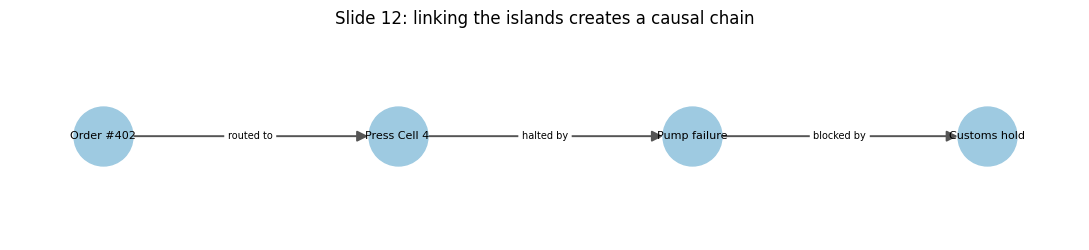

In [ ]:
# ---------------------------------------------------------
# Step 1: Slide 11 — a node is a fact/entity, an edge is a labelled link
# ---------------------------------------------------------
minimal = nx.DiGraph()
minimal.add_edge("A", "B", relation="relates to")
print("Slide 11 pattern:", [(u, d["relation"], v) for u, v, d in minimal.edges(data=True)])

# ---------------------------------------------------------
# Step 2: Slide 12 — the causal chain, built programmatically
# ---------------------------------------------------------
causal_chain = nx.DiGraph()
causal_chain.add_edge("Order #402", "Press Cell 4", relation="routed to")
causal_chain.add_edge("Press Cell 4", "Pump failure", relation="halted by")
causal_chain.add_edge("Pump failure", "Customs hold", relation="blocked by")

print("\nNodes:", list(causal_chain.nodes()))
print("Edges:")
for u, v, d in causal_chain.edges(data=True):
    print(f"  {u:<13} --{d['relation']:^12}--> {v}")
print(f"\nNumber of nodes : {causal_chain.number_of_nodes()}")
print(f"Number of edges : {causal_chain.number_of_edges()}")
print(f"Directed acyclic: {nx.is_directed_acyclic_graph(causal_chain)}")
print("Source (symptom):", [n for n in causal_chain if causal_chain.in_degree(n) == 0])
print("Sink (root)     :", [n for n in causal_chain if causal_chain.out_degree(n) == 0])

draw_graph(causal_chain, "Slide 12: linking the islands creates a causal chain",
           pos=line_layout(causal_chain.nodes()), edge_label_attr="relation", figsize=(11, 2.6))

### Execution Topic 5.2: Connect the Islands — a Graph Built from Chunks A–D

**What it does:** turns the four isolated chunks into one graph. Every edge keeps a pointer to the **chunk that states it** (its evidence). The emergency seals appear as their own node, because chunk C says the repair *requires* them and chunk D says *they* were held.

**Why it matters:** the graph is the missing connective tissue between silos. (In Part 7 we extract these edges automatically.)

**Observe:** 6 nodes, 5 edges, drawn from 4 different silos.

Nodes: 6 | Edges: 5 | Silos contributing edges: 4


,source,relation,target,evidence,silo
0,BMW,reported delay on,Order #402,C01,Sales CRM
1,Order #402,routed to,Press Cell 4,C02,Factory Floor Logs
2,Press Cell 4,halted by,Hydraulic Pump Seal Failure,C03,Maintenance Tickets
3,Hydraulic Pump Seal Failure,requires,Emergency Seals,C03,Maintenance Tickets
4,Emergency Seals,blocked by,Customs Hold,C04,Procurement Invoices


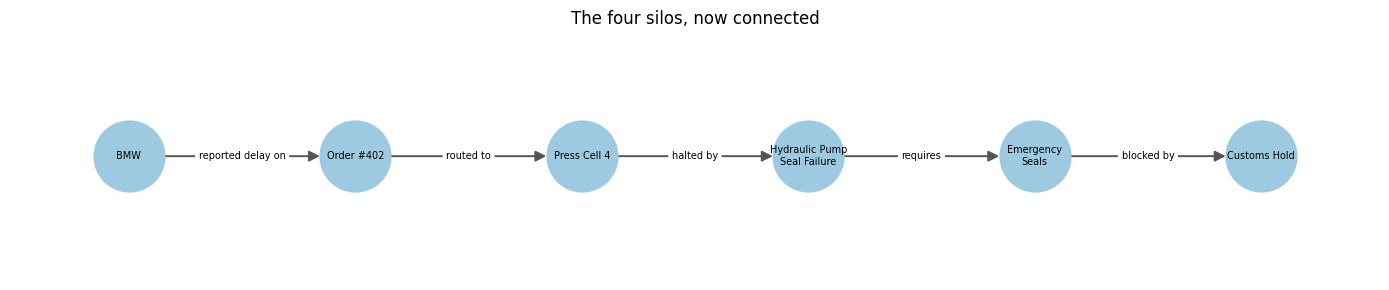

In [ ]:
# ---------------------------------------------------------
# Hand-annotated triples from chunks A-D: (source, relation, target, evidence chunk)
# (Part 7 automates this extraction step.)
# ---------------------------------------------------------
case_triples = [
    ("BMW",                          "reported delay on", "Order #402",                  "C01"),
    ("Order #402",                   "routed to",         "Press Cell 4",                "C02"),
    ("Press Cell 4",                 "halted by",         "Hydraulic Pump Seal Failure", "C03"),
    ("Hydraulic Pump Seal Failure",  "requires",          "Emergency Seals",             "C03"),
    ("Emergency Seals",              "blocked by",        "Customs Hold",                "C04"),
]
case_graph = nx.DiGraph()
for s, rel, t, cid in case_triples:
    case_graph.add_edge(s, t, relation=rel, evidence=cid,
                        silo=chunks_df.loc[chunks_df.chunk_id == cid, "silo"].iloc[0])

print(f"Nodes: {case_graph.number_of_nodes()} | Edges: {case_graph.number_of_edges()} | "
      f"Silos contributing edges: {len({d['silo'] for _, _, d in case_graph.edges(data=True)})}")
display(pd.DataFrame([{"source": u, "relation": d["relation"], "target": v, "evidence": d["evidence"], "silo": d["silo"]}
                      for u, v, d in case_graph.edges(data=True)]))
draw_graph(case_graph, "The four silos, now connected",
           pos=line_layout(["BMW", "Order #402", "Press Cell 4", "Hydraulic Pump Seal Failure", "Emergency Seals", "Customs Hold"], gap=2.4),
           edge_label_attr="relation", figsize=(14, 3), node_size=2600, font_size=7)

### Execution Topic 5.3: Multi-Hop Traversal — Walk from Symptom to Root Cause

**What it does:** runs a path search from `Order #402` to `Customs Hold`, then a generic "follow the arrows until nothing is left" walk to find the root cause(s).

**Why it matters (slide 12):** *"A graph like this connects causes with effects so the model can walk from symptom → root cause."* Each hop crosses into another silo — exactly the hops cosine search cannot make.

**Observe:** a 4-hop path, every hop backed by a citable chunk.

In [ ]:
# ---------------------------------------------------------
# Step 1: Path search (breadth-first shortest path on the directed graph)
# ---------------------------------------------------------
path = nx.shortest_path(case_graph, "Order #402", "Customs Hold")
print("Causal path:")
print(path[0])
for u, v in zip(path, path[1:]):
    d = case_graph.edges[u, v]
    print(f"  -> [{d['relation']}] {v:<30} (evidence {d['evidence']}, {d['silo']})")
print(f"\nHops: {len(path) - 1} | Silos crossed: {len({case_graph.edges[u, v]['silo'] for u, v in zip(path, path[1:])})}")

# ---------------------------------------------------------
# Step 2: Generic symptom -> root-cause walk: follow edges until a sink is reached
# ---------------------------------------------------------
reachable = nx.descendants(case_graph, "Order #402")
root_causes = [n for n in reachable if case_graph.out_degree(n) == 0]
print("Everything downstream of Order #402:", sorted(reachable))
print("Root cause(s) reached:", root_causes)

Causal path:
Order #402
  -> [routed to] Press Cell 4                   (evidence C02, Factory Floor Logs)
  -> [halted by] Hydraulic Pump Seal Failure    (evidence C03, Maintenance Tickets)
  -> [requires] Emergency Seals                (evidence C03, Maintenance Tickets)
  -> [blocked by] Customs Hold                   (evidence C04, Procurement Invoices)

Hops: 4 | Silos crossed: 3
Everything downstream of Order #402: ['Customs Hold', 'Emergency Seals', 'Hydraulic Pump Seal Failure', 'Press Cell 4']
Root cause(s) reached: ['Customs Hold']


### Execution Topic 5.4: Vector Retrieval vs. Graph Traversal on the Same Data

**What it does:** compares the two approaches on the executive question using the same four chunks and the same four-link checklist from Topic 4.2.

**Observe (slide 13, "Better odds with a graph"):** traversal collects the evidence chunks along the path and covers all four links; top-k retrieval covers one or two.

,Vector RAG (top-1),Vector RAG (top-2),Graph traversal
1. Delay confirmed (symptom),FOUND,FOUND,FOUND
2. Order routed to Press Cell 4,missing,FOUND,FOUND
3. Root cause: hydraulic pump seal failure,missing,missing,FOUND
4. Blocker: emergency seals in customs,missing,missing,FOUND
Links covered (of 4),1,2,4


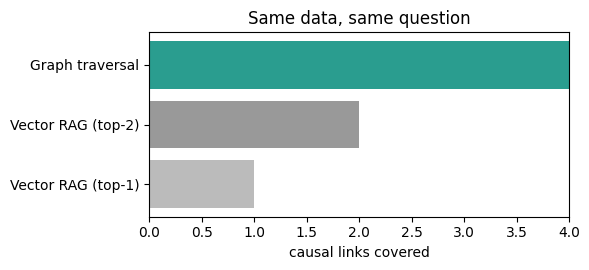

In [ ]:
# ---------------------------------------------------------
# Evidence each approach puts in front of the LLM
# ---------------------------------------------------------
vector_k1 = vector_search(executive_question, k=1, store_df=case_df, store_embeddings=case_embeddings)
vector_k2 = vector_search(executive_question, k=2, store_df=case_df, store_embeddings=case_embeddings)
path_chunks = sorted({case_graph.edges[u, v]["evidence"] for u, v in zip(path, path[1:])} | {"C01"})
graph_texts = chunks_df.loc[chunks_df.chunk_id.isin(path_chunks), "text"]

results = {
    "Vector RAG (top-1)": vector_k1["text"],
    "Vector RAG (top-2)": vector_k2["text"],
    "Graph traversal":    graph_texts,
}
comparison = pd.DataFrame({name: link_coverage(texts) for name, texts in results.items()})
comparison.loc["Links covered (of 4)"] = [sum(v == "FOUND" for v in comparison[c]) for c in comparison.columns]
display(comparison)

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(list(results), comparison.loc["Links covered (of 4)"].astype(int), color=["#bbbbbb", "#999999", "#2a9d8f"])
ax.set_xlim(0, 4); ax.set_xlabel("causal links covered"); ax.set_title("Same data, same question")
plt.tight_layout(); plt.show()

*"How can we build such a graph for an entire corpus? — **LLMs!** Isn't that expensive? — Yes: indexing is costly, but it is done **offline** and reused across many queries."* (slide 13)

## Part 6 — Graph RAG Architecture (slides 14–16)

Graph RAG splits into two tasks: **1. Indexing** (offline, one-time graph construction) and **2. Retrieval / Querying** (online, answer the user query).

### Execution Topic 6.1: The Two Pipelines, Mapped to This Notebook

**What it does:** prints the boxes of slide 15 (offline indexing) and slide 16 (online retrieval) as a table, with the execution topic that implements each box.

**Observe:** use this as the class roadmap for the rest of the session.

In [ ]:
pipeline = [
    ("1. Indexing (offline)", "Data / Documents -> Data Chunks",               "7.1"),
    ("1. Indexing (offline)", "LLM: extract entities & relations",              "7.2, 7.3"),
    ("1. Indexing (offline)", "Knowledge Graph Construction",                    "7.4, 7.5"),
    ("1. Indexing (offline)", "Community Detection (Leiden)",                    "8.1 - 8.6"),
    ("1. Indexing (offline)", "Community Summarisation (roll-up)",               "8.7"),
    ("1. Indexing (offline)", "Embedder -> Chunk / Entity / Community-report DBs", "9.1"),
    ("2. Retrieval (online)", "Query Router -> Local | Global",                   "10.1"),
    ("2. Retrieval (online)", "Local: entity search -> k-hop -> grounded chunks", "10.2 - 10.5"),
    ("2. Retrieval (online)", "Global: community search -> Map -> Filter -> Reduce", "10.6 - 10.9"),
    ("2. Retrieval (online)", "Hybrid (DRIFT)",                                   "10.10"),
]
display(pd.DataFrame(pipeline, columns=["task", "box in slides 15-16", "execution topic"]))

,task,box in slides 15-16,execution topic
0,1. Indexing (offline),Data / Documents -> Data Chunks,7.1
1,1. Indexing (offline),LLM: extract entities & relations,"7.2, 7.3"
2,1. Indexing (offline),Knowledge Graph Construction,"7.4, 7.5"
3,1. Indexing (offline),Community Detection (Leiden),8.1 - 8.6
4,1. Indexing (offline),Community Summarisation (roll-up),8.7
5,1. Indexing (offline),Embedder -> Chunk / Entity / Community-report DBs,9.1
6,2. Retrieval (online),Query Router -> Local | Global,10.1
7,2. Retrieval (online),Local: entity search -> k-hop -> grounded chunks,10.2 - 10.5
8,2. Retrieval (online),Global: community search -> Map -> Filter -> Reduce,10.6 - 10.9
9,2. Retrieval (online),Hybrid (DRIFT),10.10


### Execution Topic 6.2: Offline Cost Is Paid Once — Amortisation over Queries

**Mathematical intuition**

$$\text{cost per query}(N) = \frac{C_{\text{index}}}{N} + C_{\text{query}}$$

Where $C_{\text{index}}$ = one-time offline indexing cost, $C_{\text{query}}$ = online cost of each query, $N$ = number of queries served by the same index.

**What it does:** compares vector-RAG and Graph-RAG indexing using this notebook's own corpus size. Costs are in **illustrative units** (1 unit = one embedding call, 50 units = one LLM call) — *not* real prices.

**Observe:** Graph RAG's index costs far more, but the gap per query shrinks as $N$ grows — the "done offline, reused across many queries" argument of slide 13.

Offline index cost  (illustrative units): vector = 17, graph = 1450 (85x)


,queries N,vector cost/query,graph cost/query
0,1,68.0,1651.0
1,10,52.7,346.0
2,100,51.2,215.5
3,1000,51.0,202.4
4,10000,51.0,201.1


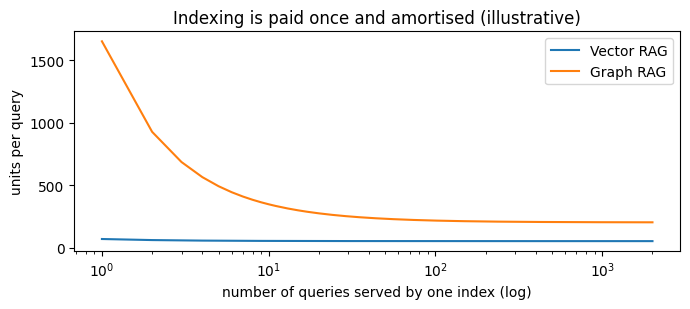

In [ ]:
# ---------------------------------------------------------
# ILLUSTRATIVE cost units (not real prices)
# ---------------------------------------------------------
EMBED_CALL, LLM_CALL = 1, 50
n_chunks = len(chunks_df)
n_entities_est, n_reports_est = 22, 11       # sizes this notebook actually produces in Parts 7-8

vector_index = n_chunks * EMBED_CALL
graph_index = (n_chunks * LLM_CALL                                 # entity/relation extraction per chunk
               + n_reports_est * LLM_CALL                          # community summaries
               + (n_chunks + n_entities_est + n_reports_est) * EMBED_CALL)   # three embedding stores
vector_query = EMBED_CALL + LLM_CALL
graph_query = EMBED_CALL + 4 * LLM_CALL                           # e.g. global: 3 map calls + 1 reduce call

print(f"Offline index cost  (illustrative units): vector = {vector_index}, graph = {graph_index} "
      f"({graph_index / vector_index:.0f}x)")
rows = []
for N in [1, 10, 100, 1000, 10000]:
    rows.append({"queries N": N,
                 "vector cost/query": round(vector_index / N + vector_query, 1),
                 "graph cost/query": round(graph_index / N + graph_query, 1)})
display(pd.DataFrame(rows))

N = np.arange(1, 2001)
plt.figure(figsize=(7, 3.2))
plt.plot(N, vector_index / N + vector_query, label="Vector RAG")
plt.plot(N, graph_index / N + graph_query, label="Graph RAG")
plt.xscale("log"); plt.xlabel("number of queries served by one index (log)"); plt.ylabel("units per query")
plt.title("Indexing is paid once and amortised (illustrative)"); plt.legend(); plt.tight_layout(); plt.show()

## Part 7 — Indexing Pipeline (slides 17–20)

**Step 1** Chunks → **Step 2** Extract → **Step 3** Graph → **Step 4** Communities → **Step 5** Summaries

### Execution Topic 7.1: Step 1 — Chunk-Size Design Trade-off

**Mathematical intuition:** with one LLM extraction call per chunk,

$$\#\text{LLM calls} = \#\text{chunks} \approx \left\lceil \frac{\text{corpus words}}{\text{chunk size}} \right\rceil$$

**What it does:** re-chunks the whole archive at several sizes and counts LLM calls. To make slide 18's second half visible (*"but weaker recall of early facts"*), it applies an **illustrative** recall model in which a fact is less likely to be extracted the more text follows it inside the same chunk.

**Observe:** larger chunks ⇒ fewer calls, but lower expected recall. The recall curve is a *simulation of the stated trade-off*, not a measurement.

Corpus: 214 words, 17 facts


,chunk size (words),LLM calls = chunks,ceil(words/size),expected facts recalled,recall %
0,25,12,9,16.8,98.8
1,50,5,5,16.0,94.1
2,100,3,3,14.0,82.4
3,200,2,2,10.9,64.0
4,400,1,1,10.1,59.2


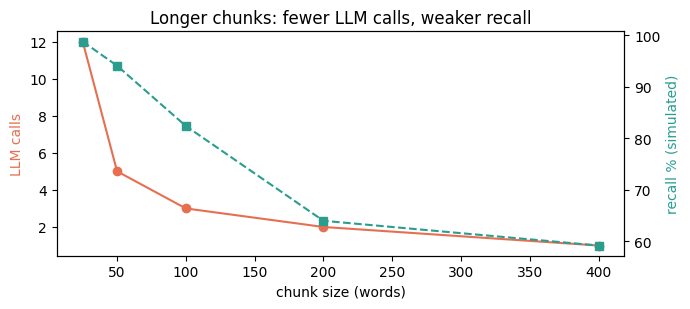

In [ ]:
# ---------------------------------------------------------
# Step 1: One long corpus (all records in date order), each record = one fact
# ---------------------------------------------------------
corpus_records = list(archive_df.sort_values("date")[["record_id", "text"]].itertuples(index=False, name=None))
record_len = {rid: len(t.split()) for rid, t in corpus_records}
total_words = sum(record_len.values())

# ---------------------------------------------------------
# Step 2: ILLUSTRATIVE recall model — facts buried early in a long chunk are
# recalled less often (encodes slide 18's statement; not measured from an LLM)
# ---------------------------------------------------------
def simulated_recall(words_after_fact):
    return max(0.3, 1.0 - 0.004 * words_after_fact)

rows = []
for size in [25, 50, 100, 200, 400]:
    chunks = chunk_document(corpus_records, size)
    expected_recalled = 0.0
    for chunk_id, _ in chunks:
        ids = chunk_id.split("+")
        for i, rid in enumerate(ids):
            words_after = sum(record_len[x] for x in ids[i + 1:])
            expected_recalled += simulated_recall(words_after)
    rows.append({"chunk size (words)": size, "LLM calls = chunks": len(chunks),
                 "ceil(words/size)": math.ceil(total_words / size),
                 "expected facts recalled": round(expected_recalled, 1),
                 "recall %": round(100 * expected_recalled / len(corpus_records), 1)})
tradeoff = pd.DataFrame(rows)
print(f"Corpus: {total_words} words, {len(corpus_records)} facts")
display(tradeoff)

fig, ax1 = plt.subplots(figsize=(7, 3.2))
ax1.plot(tradeoff.iloc[:, 0], tradeoff["LLM calls = chunks"], "o-", color="#e76f51"); ax1.set_ylabel("LLM calls", color="#e76f51")
ax2 = ax1.twinx(); ax2.plot(tradeoff.iloc[:, 0], tradeoff["recall %"], "s--", color="#2a9d8f"); ax2.set_ylabel("recall % (simulated)", color="#2a9d8f")
ax1.set_xlabel("chunk size (words)"); ax1.set_title("Longer chunks: fewer LLM calls, weaker recall")
plt.tight_layout(); plt.show()

### Execution Topic 7.2: Step 2 — Extract Entities, Relations and Claims (slide 19 example)

**What it does:** runs an extractor on the exact NeoChip paragraph from slide 19. In production an **LLM** does this; here a transparent rule-based stand-in does it, so no API key is needed:
* **Entities** — matched from a small catalogue (name, type, aliases)
* **Relations** — a typed pattern between two consecutive entities in a sentence (e.g. *Chipmaker … "was acquired by" … Owner* ⇒ `Owner —owned→ Chipmaker`)
* **Claims** — dated statements (clauses containing a date or time expression)

**Observe:** the output reproduces slide 19: entities NeoChip, Quantum Systems, NewTech Exchange; relations `Quantum Systems —owned→ NeoChip` and `NeoChip —listed on→ NewTech`; claims about week 1 and 2016.

In [ ]:
# ---------------------------------------------------------
# Step 1: Generic extractor = entity matching + typed relation patterns + dated claims
# (a deterministic stand-in for the LLM extraction call of slide 19)
# ---------------------------------------------------------
TIME_EXPR = re.compile(r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?\s+\d{1,2}\b"
                       r"|\b(19|20)\d{2}\b|\bfirst week\b|\b\d+-(day|week)\b", re.IGNORECASE)

def find_mentions(text, catalog):
    """Find catalogue entities in text (longest alias first, no overlaps)."""
    aliases = sorted(((a, name) for name, info in catalog.items() for a in [name] + info.get("aliases", [])),
                     key=lambda x: -len(x[0]))
    taken, found = [False] * len(text), []
    for alias, name in aliases:
        for m in re.finditer(r"(?<!\w)" + re.escape(alias) + r"(?!\w)", text, flags=re.IGNORECASE):
            if any(taken[m.start():m.end()]):
                continue
            taken[m.start():m.end()] = [True] * (m.end() - m.start())
            found.append({"entity": name, "type": catalog[name]["type"], "surface": m.group(0),
                          "start": m.start(), "end": m.end()})
    return sorted(found, key=lambda x: x["start"])

def extract_graph_elements(text, chunk_id, catalog, schema):
    entities, relations, claims = [], [], []
    for sentence in re.split(r"(?<=[.!?])\s+", text.strip()):
        mentions = find_mentions(sentence, catalog)
        entities += [{"chunk_id": chunk_id, "entity": m["entity"], "type": m["type"], "surface": m["surface"]} for m in mentions]
        # Relations: test each pair of consecutive entity mentions against the typed patterns
        for m1, m2 in zip(mentions, mentions[1:]):
            if m1["entity"] == m2["entity"]:
                continue
            between = sentence[m1["end"]:m2["start"]].lower()
            for rule in schema:
                if (m1["type"], m2["type"]) == (rule["src_type"], rule["dst_type"]) and re.search(rule["pattern"], between):
                    src, dst = (m2, m1) if rule.get("reverse") else (m1, m2)
                    relations.append({"chunk_id": chunk_id, "source": src["entity"], "relation": rule["relation"],
                                      "target": dst["entity"], "source_surface": src["surface"],
                                      "target_surface": dst["surface"], "evidence": sentence.strip()})
                    break
        # Claims: clauses that carry a date / time expression
        for clause in re.split(r";\s*|\s+and\s+", sentence):
            if TIME_EXPR.search(clause):
                cm = find_mentions(clause, catalog) or mentions
                claims.append({"chunk_id": chunk_id, "subject": cm[0]["entity"] if cm else None,
                               "claim": clause.strip(" ."), "time": TIME_EXPR.search(clause).group(0)})
    return entities, relations, claims

# ---------------------------------------------------------
# Step 2: The slide-19 catalogue and relation patterns
# ---------------------------------------------------------
NEOCHIP_CATALOG = {
    "NeoChip":          {"type": "Chipmaker", "aliases": ["NeoChip Ltd"]},
    "Quantum Systems":  {"type": "Owner",     "aliases": ["Quantum Systems Inc"]},
    "NewTech Exchange": {"type": "Exchange",  "aliases": ["NewTech"]},
}
NEOCHIP_SCHEMA = [
    {"src_type": "Chipmaker", "dst_type": "Exchange",  "pattern": r"trading on|listed on|trades? on", "relation": "listed on"},
    {"src_type": "Chipmaker", "dst_type": "Owner",     "pattern": r"acquired by|owned by", "relation": "owned", "reverse": True},
    {"src_type": "Owner",     "dst_type": "Chipmaker", "pattern": r"acquired|owns|parent of", "relation": "owned"},
]

slide19_text = ("NeoChip's shares surged in their first week of trading on the NewTech Exchange. "
                "NeoChip was acquired by Quantum Systems in 2016 and specializes in low-power "
                "processors for wearables and IoT devices.")
ents, rels, clms = extract_graph_elements(slide19_text, "N1", NEOCHIP_CATALOG, NEOCHIP_SCHEMA)

print("Chunk:", slide19_text, "\n")
print("[SIMULATED extraction - rule-based stand-in for the LLM]")
print("Entities :", "; ".join(sorted({f"{e['entity']} ({e['type'].lower()})" for e in ents})))
print("Relations:", "; ".join(f"{r['source']} --{r['relation']}--> {r['target']}" for r in rels))
print("Claims   :", "; ".join(f"{c['claim']} [{c['time']}]" for c in clms))

Chunk: NeoChip's shares surged in their first week of trading on the NewTech Exchange. NeoChip was acquired by Quantum Systems in 2016 and specializes in low-power processors for wearables and IoT devices. 

[SIMULATED extraction - rule-based stand-in for the LLM]
Entities : NeoChip (chipmaker); NewTech Exchange (exchange); Quantum Systems (owner)
Relations: NeoChip --listed on--> NewTech Exchange; Quantum Systems --owned--> NeoChip
Claims   : NeoChip's shares surged in their first week of trading on the NewTech Exchange [first week]; NeoChip was acquired by Quantum Systems in 2016 [2016]


### Execution Topic 7.3: Step 2 on the BMW Archive — Extraction for Every Chunk

**What it does:** applies the same extractor to all 17 archive chunks with a manufacturing catalogue (customers, orders, machines, failures, parts, suppliers, locations, events) and manufacturing relation patterns.

**Why it matters:** this is "the LLM extracts information from each chunk" — one extraction call per chunk.

**Observe:** the triples extracted from chunks A–D are exactly the links we hand-drew in Topic 5.2 — now produced automatically.

In [ ]:
# ---------------------------------------------------------
# Step 1: Entity catalogue for the manufacturing archive
# ---------------------------------------------------------
BMW_CATALOG = {
    "BMW": {"type": "Customer"}, "Nordwerk Motors": {"type": "Customer"}, "Alpen Trucks": {"type": "Customer"},
    "Order #402": {"type": "Order"}, "Order #415": {"type": "Order"}, "Order #431": {"type": "Order"}, "Order #447": {"type": "Order"},
    "Press Cell 4": {"type": "Machine"}, "Weld Line 2": {"type": "Machine"}, "Paint Line 1": {"type": "Machine"},
    "Hydraulic Pump Seal Failure": {"type": "Failure", "aliases": ["hydraulic pump seal blowout", "pump seal blowout"]},
    "Hydraulic Oil Leak": {"type": "Failure"},
    "Paint Contamination Defect": {"type": "Failure", "aliases": ["paint rework"]},
    "Emergency Seals": {"type": "Part"}, "Steel Coils": {"type": "Part"}, "Primer Batch PB-77": {"type": "Part"},
    "SealTech GmbH": {"type": "Supplier"}, "Nordstahl AG": {"type": "Supplier"}, "ChemCoat": {"type": "Supplier"},
    "Port of Hamburg": {"type": "Location"},
    "Customs Hold": {"type": "Event"}, "Port Congestion": {"type": "Event"},
}

# ---------------------------------------------------------
# Step 2: Typed relation patterns (source type, target type, trigger words -> relation)
# ---------------------------------------------------------
BMW_SCHEMA = [dict(zip(["src_type", "dst_type", "pattern", "relation"], r)) for r in [
    ("Customer", "Order",    r"delay|escalat",       "reported delay on"),
    ("Customer", "Order",    r"^\W*$",               "placed"),
    ("Order",    "Machine",  r"scheduled on|routed", "routed to"),
    ("Order",    "Machine",  r"after|due to",        "delayed by downtime of"),
    ("Order",    "Failure",  r"due to|after",        "delayed by"),
    ("Machine",  "Failure",  r"halted|stopped",      "halted by"),
    ("Machine",  "Part",     r"waiting for",         "waiting for"),
    ("Failure",  "Part",     r"requires",            "requires"),
    ("Failure",  "Part",     r"traced to",           "caused by"),
    ("Part",     "Event",    r"delayed|held|blocked", "blocked by"),
    ("Part",     "Location", r"delayed at",          "delayed at"),
    ("Part",     "Location", r"via",                 "shipped via"),
    ("Supplier", "Part",     r"shipped|supplied",    "supplies"),
    ("Location", "Event",    r"\(|by|due to",        "affected by"),
]]

# ---------------------------------------------------------
# Step 3: One extraction "call" per chunk
# ---------------------------------------------------------
all_entities, all_relations, all_claims = [], [], []
for r in chunks_df.itertuples():
    e, rel, c = extract_graph_elements(r.text, r.chunk_id, BMW_CATALOG, BMW_SCHEMA)
    all_entities += e; all_relations += rel; all_claims += c
mentions_df = pd.DataFrame(all_entities)
raw_relations_df = pd.DataFrame(all_relations)
claims_df = pd.DataFrame(all_claims)

print("[SIMULATED extraction - rule-based stand-in for the LLM]")
print(f"Extraction calls: {len(chunks_df)} | entity mentions: {len(mentions_df)} | "
      f"relations: {len(raw_relations_df)} | claims: {len(claims_df)}\n")
print("Triples extracted from chunks A-D:")
display(raw_relations_df[raw_relations_df.chunk_id.isin(["C01", "C02", "C03", "C04"])][["chunk_id", "source", "relation", "target"]])
print("Sample dated claims:")
display(claims_df.head(5))

[SIMULATED extraction - rule-based stand-in for the LLM]
Extraction calls: 17 | entity mentions: 47 | relations: 30 | claims: 16

Triples extracted from chunks A-D:


,chunk_id,source,relation,target
0,C01,BMW,reported delay on,Order #402
1,C02,BMW,placed,Order #402
2,C02,Order #402,routed to,Press Cell 4
3,C03,Press Cell 4,halted by,Hydraulic Pump Seal Failure
4,C03,Hydraulic Pump Seal Failure,requires,Emergency Seals
5,C04,Emergency Seals,blocked by,Customs Hold


Sample dated claims:


,chunk_id,subject,claim,time
0,C01,BMW,BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28),3-week
1,C02,BMW,BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2),Aug 2
2,C03,Press Cell 4,Press Cell 4 halted (Aug 10): hydraulic pump seal blowout,Aug 10
3,C05,SealTech GmbH,SealTech GmbH shipped the emergency seals via Port of Hamburg (Aug 6),Aug 6
4,C06,Press Cell 4,Press Cell 4 halted again (Sep 3): hydraulic oil leak,Sep 3


### Execution Topic 7.4: Step 3 — Build the Knowledge Graph: Merge Duplicates, Count Edge Weights

**Mathematical intuition (slide 20)**

$$w(u, v) = \sum_{\text{chunks } c} \mathbb{1}\big[\text{relation } u \to v \text{ extracted from } c\big]$$

Nodes = unique entities, edges = unique relationships, **edge weight** = how often that link was extracted (a stronger, more-supported link).

**What it does:** runs extraction over 8 NeoChip news chunks that use different surface forms (*Quantum Systems Inc*, *NeoChip Ltd*), merges them to canonical nodes, merges duplicate edges, and counts weights. Node and edge descriptions are aggregated.

**Observe:** `Quantum Systems → NeoChip, weight = 7` — slide 20's example — verified two ways.

Raw extracted relations (before merging): 10


,chunk_id,source_surface,target_surface,source,relation,target
0,N1,NeoChip,NewTech Exchange,NeoChip,listed on,NewTech Exchange
1,N1,Quantum Systems,NeoChip,Quantum Systems,owned,NeoChip
2,N2,Quantum Systems Inc,NeoChip,Quantum Systems,owned,NeoChip
3,N3,Quantum Systems,NeoChip Ltd,Quantum Systems,owned,NeoChip
4,N4,Quantum Systems,NeoChip,Quantum Systems,owned,NeoChip
5,N5,Quantum Systems,NeoChip,Quantum Systems,owned,NeoChip
6,N6,Quantum Systems,NeoChip,Quantum Systems,owned,NeoChip
7,N7,Quantum Systems,NeoChip,Quantum Systems,owned,NeoChip
8,N7,NeoChip,NewTech Exchange,NeoChip,listed on,NewTech Exchange
9,N8,NeoChip,NewTech Exchange,NeoChip,listed on,NewTech Exchange


Surface forms seen: 5 -> unique nodes: 3
Raw relation rows : 10 -> unique edges: 2

NeoChip --listed on--> NewTech Exchange   Edge weight = 3   (chunks N1, N7, N8)
Quantum Systems --owned--> NeoChip   Edge weight = 7   (chunks N1, N2, N3, N4, N5, N6, N7)

Verification with Counter: {('NeoChip', 'NewTech Exchange'): 3, ('Quantum Systems', 'NeoChip'): 7}


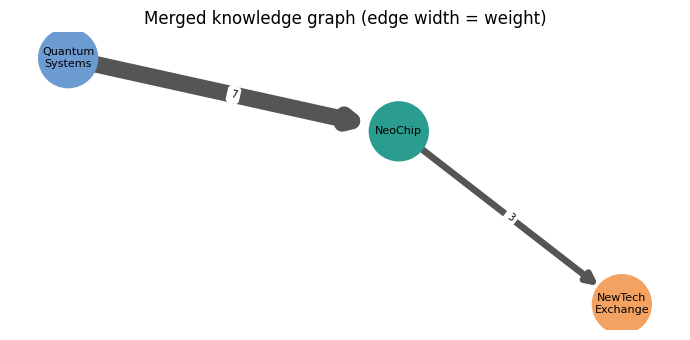

In [ ]:
# ---------------------------------------------------------
# Step 1: Many chunks mention the same entities and relation
# ---------------------------------------------------------
neochip_chunks = {
    "N1": slide19_text,
    "N2": "Quantum Systems Inc acquired NeoChip to expand its wearables portfolio.",
    "N3": "NeoChip Ltd, owned by Quantum Systems, shipped a new IoT processor.",
    "N4": "Quantum Systems owns NeoChip and its low-power chip patents.",
    "N5": "NeoChip was acquired by Quantum Systems in 2016 for its IoT expertise.",
    "N6": "Quantum Systems, parent of NeoChip, reported record wearables revenue.",
    "N7": "Quantum Systems acquired NeoChip; NeoChip trades on the NewTech Exchange.",
    "N8": "NeoChip shares trade on the NewTech Exchange under the ticker NCHP.",
}
raw = []
for cid, text in neochip_chunks.items():
    raw += extract_graph_elements(text, cid, NEOCHIP_CATALOG, NEOCHIP_SCHEMA)[1]
raw_df = pd.DataFrame(raw)
print(f"Raw extracted relations (before merging): {len(raw_df)}")
display(raw_df[["chunk_id", "source_surface", "target_surface", "source", "relation", "target"]])

# ---------------------------------------------------------
# Step 2: Merge duplicates -> unique nodes, unique edges, weight = count
# ---------------------------------------------------------
def merge_to_graph(relations_df):
    G = nx.DiGraph()
    for (s, t), grp in relations_df.groupby(["source", "target"]):
        G.add_edge(s, t, weight=len(grp), relations=sorted(set(grp["relation"])),
                   chunks=sorted(set(grp["chunk_id"])),
                   relation_chunks={r: sorted(set(g["chunk_id"])) for r, g in grp.groupby("relation")},
                   description=" | ".join(sorted(set(grp["evidence"]))))   # aggregated edge description
    return G

neochip_graph = merge_to_graph(raw_df)
surface_forms = raw_df.melt(value_vars=["source_surface", "target_surface"])["value"].nunique()
print(f"Surface forms seen: {surface_forms} -> unique nodes: {neochip_graph.number_of_nodes()}")
print(f"Raw relation rows : {len(raw_df)} -> unique edges: {neochip_graph.number_of_edges()}\n")
for u, v, d in neochip_graph.edges(data=True):
    print(f"{u} --{'/'.join(d['relations'])}--> {v}   Edge weight = {d['weight']}   (chunks {', '.join(d['chunks'])})")

# ---------------------------------------------------------
# Step 3: Verify the weight independently with a Counter
# ---------------------------------------------------------
counter = Counter(zip(raw_df.source, raw_df.target))
print("\nVerification with Counter:", dict(counter))
draw_graph(neochip_graph, "Merged knowledge graph (edge width = weight)", edge_label_attr="weight", width_attr="weight",
           node_color=[TYPE_COLORS[NEOCHIP_CATALOG[n]["type"]] for n in neochip_graph.nodes()], figsize=(7, 3.5))

### Execution Topic 7.5: Step 3 on the BMW Archive — The Q3 Knowledge Graph

**What it does:** merges all BMW-archive extractions into one knowledge graph `kg`. Every node stores its type, the chunks that mention it (its **text units**) and an aggregated description; every edge stores weight, relation labels and evidence chunks.

**Observe:** graph statistics, weight-2 edges (links stated in two separate chunks), and a picture coloured by entity type. Note the separate paint-shop island — no document links it to the others.

Nodes: 22 | Edges: 23 | Weakly-connected components: 2
Nodes per type: {'Customer': 3, 'Order': 4, 'Supplier': 3, 'Part': 3, 'Event': 2, 'Location': 1, 'Failure': 3, 'Machine': 3}

Edges extracted from two separate chunks (weight = 2):
  Alpen Trucks --placed/reported delay on--> Order #431  weight=2 chunks=['C14', 'C17']
  BMW --placed/reported delay on--> Order #402  weight=2 chunks=['C01', 'C02']
  BMW --placed/reported delay on--> Order #447  weight=2 chunks=['C07', 'C08']
  Order #447 --delayed by downtime of/routed to--> Press Cell 4  weight=2 chunks=['C07', 'C08']
  Steel Coils --delayed at/shipped via--> Port of Hamburg  weight=2 chunks=['C11', 'C12']
  Nordwerk Motors --placed/reported delay on--> Order #415  weight=2 chunks=['C09', 'C10']
  Order #415 --delayed by downtime of/routed to--> Weld Line 2  weight=2 chunks=['C09', 'C10']

Example node description: Press Cell 4 (Machine). Order #402 routed to Press Cell 4; Order #447 delayed by downtime of/routed to Press Cell 4; Pr

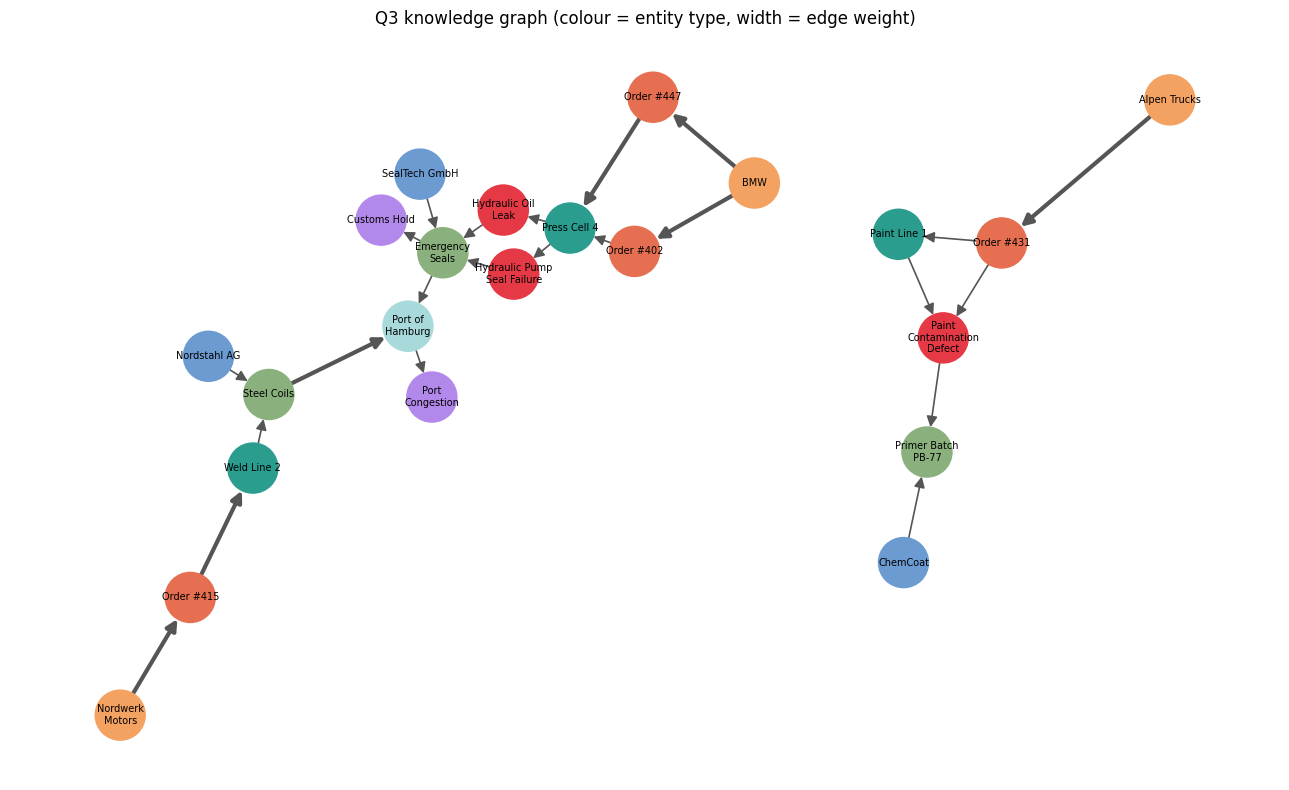

In [ ]:
# ---------------------------------------------------------
# Step 1: Merge extracted relations into the knowledge graph
# ---------------------------------------------------------
kg = merge_to_graph(raw_relations_df)

# ---------------------------------------------------------
# Step 2: Node attributes: type, text units (chunks), aggregated description
# ---------------------------------------------------------
for node in kg.nodes():
    facts = [f"{u} {'/'.join(d['relations'])} {v}" for u, v, d in kg.in_edges(node, data=True)] + \
            [f"{u} {'/'.join(d['relations'])} {v}" for u, v, d in kg.out_edges(node, data=True)]
    node_claims = claims_df.loc[claims_df.subject == node, "claim"].tolist()
    kg.nodes[node].update(
        type=BMW_CATALOG[node]["type"],
        chunks=sorted(set(mentions_df.loc[mentions_df.entity == node, "chunk_id"])),
        description=f"{node} ({BMW_CATALOG[node]['type']}). " + "; ".join(facts + node_claims))

print(f"Nodes: {kg.number_of_nodes()} | Edges: {kg.number_of_edges()} | "
      f"Weakly-connected components: {nx.number_weakly_connected_components(kg)}")
print("Nodes per type:", dict(Counter(nx.get_node_attributes(kg, 'type').values())))
print("\nEdges extracted from two separate chunks (weight = 2):")
for u, v, d in kg.edges(data=True):
    if d["weight"] > 1:
        print(f"  {u} --{'/'.join(d['relations'])}--> {v}  weight={d['weight']} chunks={d['chunks']}")
print("\nExample node description:", kg.nodes["Press Cell 4"]["description"])

kg_pos = component_layout(kg)
draw_graph(kg, "Q3 knowledge graph (colour = entity type, width = edge weight)", pos=kg_pos, width_attr="weight",
           node_color=[TYPE_COLORS[kg.nodes[n]["type"]] for n in kg.nodes()], node_size=1300, font_size=7, figsize=(13, 8))

## Part 8 — Communities, Leiden, Hierarchy and Roll-up (slides 21–25)

### Execution Topic 8.1: But the Graph Is Huge — Why Walking It at Query Time Fails

**What it does:** generates a synthetic 3,000-node knowledge graph with 30 hidden topic groups (the scale slide 21 warns about), then measures how fast a k-hop walk from one node swallows the graph.

**Why it matters:** *"Walking the whole graph at query time is slow, noisy, and hard to scale."* Graphs, however, naturally form **communities**.

**Observe:** by 3–4 hops the walk touches most of the graph (noise), while the start node's own community is only ~100 nodes.

In [ ]:
# ---------------------------------------------------------
# Step 1: A large synthetic graph with 30 densely-connected groups
# ---------------------------------------------------------
n_groups, group_size = 30, 100
probs = np.full((n_groups, n_groups), 0.0015)   # sparse links BETWEEN groups
np.fill_diagonal(probs, 0.05)                   # dense links INSIDE a group
big_graph = nx.stochastic_block_model([group_size] * n_groups, probs.tolist(), seed=SEED)
print(f"Synthetic knowledge graph: {big_graph.number_of_nodes():,} nodes, {big_graph.number_of_edges():,} edges")

# ---------------------------------------------------------
# Step 2: How much of the graph does a k-hop walk touch?
# ---------------------------------------------------------
start = 0
t0 = time.perf_counter()
dist = nx.single_source_shortest_path_length(big_graph, start)
walk_ms = (time.perf_counter() - t0) * 1000
rows = [{"k hops": k, "nodes reached": sum(d <= k for d in dist.values()),
         "% of graph": round(100 * sum(d <= k for d in dist.values()) / big_graph.number_of_nodes(), 1)} for k in range(1, 6)]
display(pd.DataFrame(rows))
own_group = [n for n in big_graph if big_graph.nodes[n]["block"] == big_graph.nodes[start]["block"]]
print(f"Full-graph walk from node {start}: {walk_ms:.1f} ms (grows with graph size)")
print(f"Nodes in node {start}'s own community: {len(own_group)} "
      f"({100 * len(own_group) / big_graph.number_of_nodes():.1f}% of the graph)")

Synthetic knowledge graph: 3,000 nodes, 13,702 edges


,k hops,nodes reached,% of graph
0,1,13,0.4
1,2,102,3.4
2,3,739,24.6
3,4,2663,88.8
4,5,3000,100.0


Full-graph walk from node 0: 3.5 ms (grows with graph size)
Nodes in node 0's own community: 100 (3.3% of the graph)


### Execution Topic 8.2: What Is a Community? — Friends Form Tight Circles

**What it does:** builds a small social network of three friend circles joined by a few bridge friendships (slide 22's analogy), and measures each circle's **internal** vs **external** links.

**Why it matters:** a community = nodes **densely linked to each other and only weakly linked to the outside**.

**Observe:** internal density is high (most possible friendships exist), external links are 1–2 per circle. The first picture shows the graph *before* any community detection.

,size,internal links,possible pairs,internal density,external links
Circle A,6.0,14.0,15.0,0.93,2.0
Circle B,6.0,11.0,15.0,0.73,2.0
Circle C,6.0,11.0,15.0,0.73,2.0


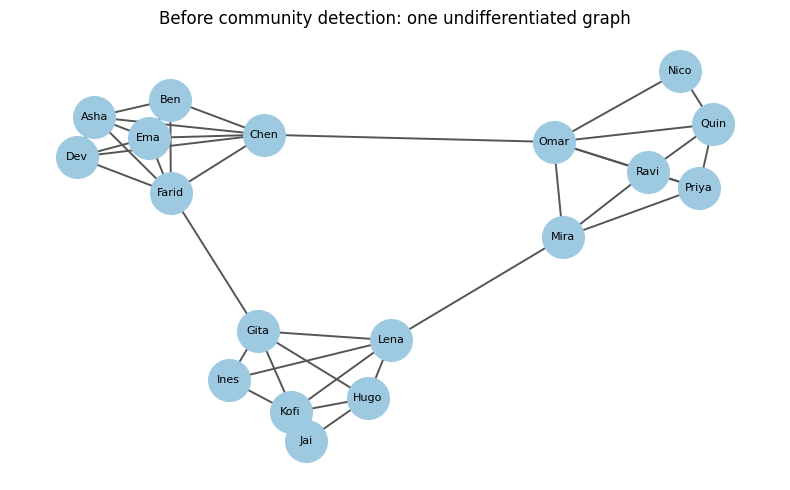

In [ ]:
# ---------------------------------------------------------
# Step 1: Three friend circles + a few bridge friendships
# ---------------------------------------------------------
circles = {
    "Circle A": ["Asha", "Ben", "Chen", "Dev", "Ema", "Farid"],
    "Circle B": ["Gita", "Hugo", "Ines", "Jai", "Kofi", "Lena"],
    "Circle C": ["Mira", "Nico", "Omar", "Priya", "Quin", "Ravi"],
}
rng = random.Random(SEED)
social = nx.Graph()
for members in circles.values():
    for i, a in enumerate(members):
        for b in members[i + 1:]:
            if rng.random() < 0.8:                    # most friends know each other
                social.add_edge(a, b)
social.add_edges_from([("Farid", "Gita"), ("Lena", "Mira"), ("Chen", "Omar")])   # weak outside links

# ---------------------------------------------------------
# Step 2: Internal vs external links per circle
# ---------------------------------------------------------
def community_stats(G, members):
    members = set(members)
    internal = sum(1 for u, v in G.edges() if u in members and v in members)
    external = sum(1 for u, v in G.edges() if (u in members) != (v in members))
    possible = len(members) * (len(members) - 1) / 2
    return {"size": len(members), "internal links": internal, "possible pairs": int(possible),
            "internal density": round(internal / possible, 2), "external links": external}

display(pd.DataFrame({c: community_stats(social, m) for c, m in circles.items()}).T)
social_pos = nx.spring_layout(social, seed=SEED)
draw_graph(social, "Before community detection: one undifferentiated graph", pos=social_pos, figsize=(8, 5), node_size=900)

### Execution Topic 8.3: The Leiden Algorithm — Detect the Communities

**What it does:** runs **Leiden** (slide 24: *"the most commonly used algorithm to detect communities in GraphRAG"*) via `leidenalg`, then verifies the two partition properties from slide 24:
* **Mutually exclusive** — every node is in exactly one community
* **Collectively exhaustive** — every node is covered

**How Leiden works (one line):** it repeatedly moves nodes between groups to increase a quality score that rewards dense-inside / sparse-outside groups, and — unlike its predecessor Louvain — refines each group so every community stays internally connected (Traag et al., 2019).

**Observe:** Leiden recovers the three circles exactly, with no labels given.

Leiden community 0: ['Mira', 'Nico', 'Omar', 'Priya', 'Quin', 'Ravi']  -> matches Circle C
Leiden community 1: ['Gita', 'Hugo', 'Ines', 'Jai', 'Kofi', 'Lena']  -> matches Circle B
Leiden community 2: ['Asha', 'Ben', 'Chen', 'Dev', 'Ema', 'Farid']  -> matches Circle A
Mutually exclusive: True | Collectively exhaustive: True


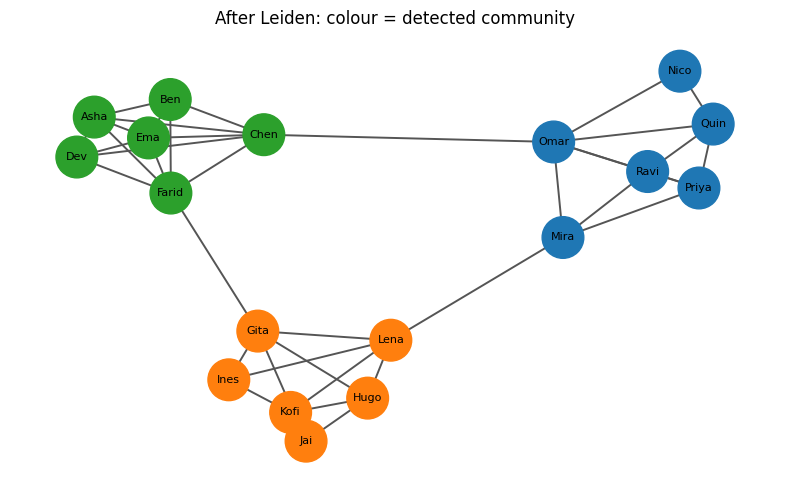

In [ ]:
# ---------------------------------------------------------
# Step 1: Leiden wrapper: networkx graph -> igraph -> leidenalg -> {node: community id}
# resolution = granularity knob (1.0 = standard; lower = bigger communities)
# ---------------------------------------------------------
def leiden_partition(G, resolution=1.0, seed=SEED):
    nodes = list(G.nodes())
    index = {n: i for i, n in enumerate(nodes)}
    g = ig.Graph(n=len(nodes), edges=[(index[u], index[v]) for u, v in G.edges()])
    weights = [G.edges[u, v].get("weight", 1) for u, v in G.edges()]
    part = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition, weights=weights,
                                    resolution_parameter=resolution, seed=seed)
    return {nodes[i]: c for i, c in enumerate(part.membership)}

def groups_of(partition):
    groups = defaultdict(list)
    for n, c in partition.items():
        groups[c].append(n)
    return dict(sorted(groups.items()))

# ---------------------------------------------------------
# Step 2: Run Leiden on the social network
# ---------------------------------------------------------
social_part = leiden_partition(social)
for c, members in groups_of(social_part).items():
    true_circle = Counter(next(k for k, v in circles.items() if m in v) for m in members).most_common(1)[0][0]
    print(f"Leiden community {c}: {sorted(members)}  -> matches {true_circle}")

# ---------------------------------------------------------
# Step 3: Verify slide 24's partition properties
# ---------------------------------------------------------
def check_partition(G, communities):
    member_lists = list(communities.values())
    all_members = [n for m in member_lists for n in m]
    exclusive = len(all_members) == len(set(all_members))
    exhaustive = set(all_members) == set(G.nodes())
    print(f"Mutually exclusive: {exclusive} | Collectively exhaustive: {exhaustive}")

check_partition(social, groups_of(social_part))
draw_graph(social, "After Leiden: colour = detected community", pos=social_pos, figsize=(8, 5), node_size=900,
           node_color=[PALETTE[social_part[n]] for n in social.nodes()])

### Execution Topic 8.4: Leiden on the BMW Knowledge Graph

**What it does:** runs Leiden on the Q3 knowledge graph (treated as undirected, using edge weights).

**Why it matters (slide 22):** *"In Graph RAG: entities that co-occur — e.g. Press Cell 4, seals, supplier."* Communities become the themes of the archive.

**Observe:** each community's members, its internal vs external links, and where Press Cell 4, the emergency seals and SealTech land.

Leiden found 5 communities in 22 entities



,community,members,size,internal links,external links
0,0,"Alpen Trucks, ChemCoat, Order #431, Paint Contamination Defect, Paint Line 1, Primer Batch PB-77",6,6,0
1,1,"Customs Hold, Emergency Seals, Hydraulic Oil Leak, Hydraulic Pump Seal Failure, SealTech GmbH",5,4,3
2,2,"Nordstahl AG, Port Congestion, Port of Hamburg, Steel Coils",4,3,2
3,3,"BMW, Order #402, Order #447, Press Cell 4",4,4,2
4,4,"Nordwerk Motors, Order #415, Weld Line 2",3,2,1


Mutually exclusive: True | Collectively exhaustive: True
  Press Cell 4     -> community 3
  Emergency Seals  -> community 1
  SealTech GmbH    -> community 1
  Customs Hold     -> community 1


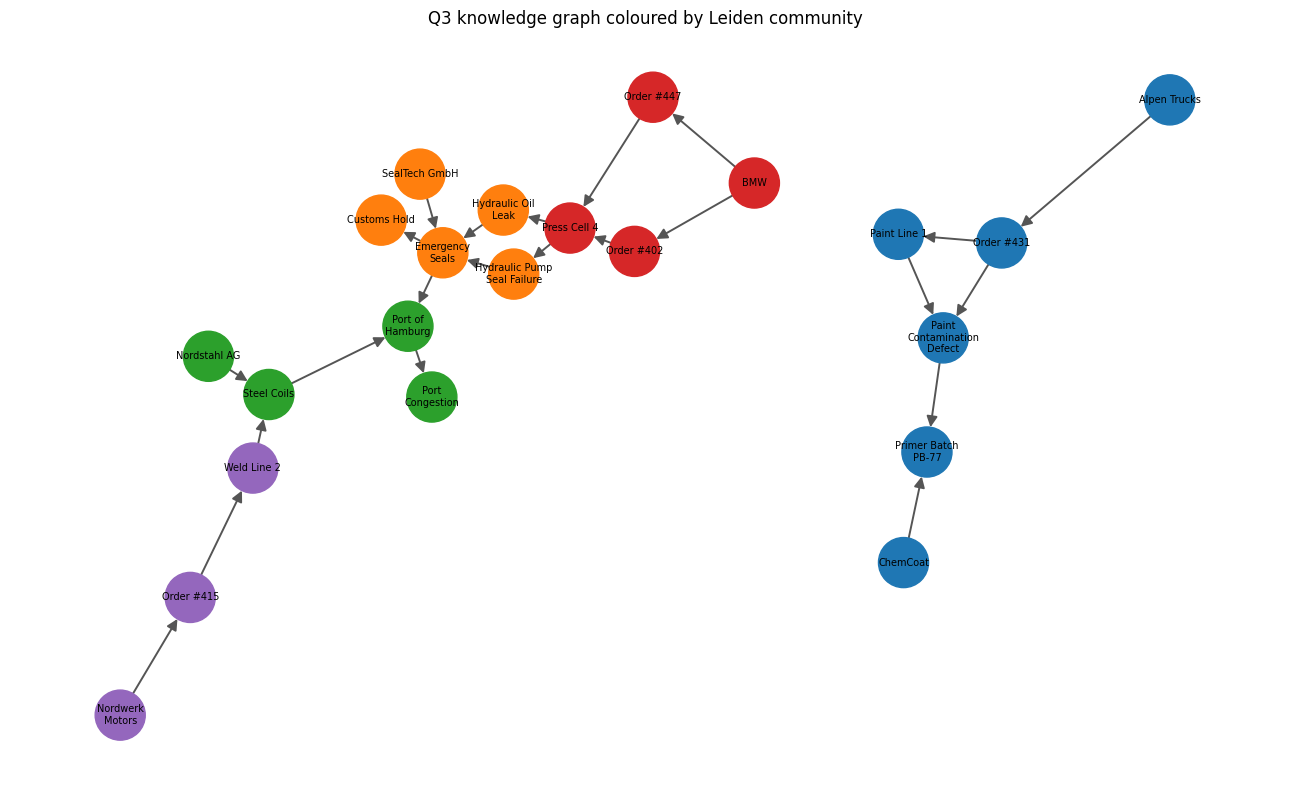

In [ ]:
# ---------------------------------------------------------
# Step 1: Community detection on the knowledge graph
# ---------------------------------------------------------
kg_undirected = kg.to_undirected()
bmw_partition = leiden_partition(kg_undirected)
bmw_groups = groups_of(bmw_partition)
print(f"Leiden found {len(bmw_groups)} communities in {kg.number_of_nodes()} entities\n")

rows = []
for c, members in bmw_groups.items():
    stats = community_stats(kg_undirected, members)
    rows.append({"community": c, "members": ", ".join(sorted(members)), **{k: stats[k] for k in ("size", "internal links", "external links")}})
display(pd.DataFrame(rows))
check_partition(kg_undirected, bmw_groups)

for entity in ["Press Cell 4", "Emergency Seals", "SealTech GmbH", "Customs Hold"]:
    print(f"  {entity:<16} -> community {bmw_partition[entity]}")

draw_graph(kg, "Q3 knowledge graph coloured by Leiden community", pos=kg_pos,
           node_color=[PALETTE[bmw_partition[n] % 10] for n in kg.nodes()], node_size=1300, font_size=7, figsize=(13, 8))

### Execution Topic 8.5: Hierarchical Communities — the University Research Archive (slide 23)

**What it does:** builds slide 23's example — a research archive of AI/CS papers (NLP, Vision) and Biology papers (Genomics, Ecology) linked by citations — and runs **Leiden hierarchically** (slide 24): Leiden on the whole graph gives Level 1; Leiden again *inside* each Level-1 community gives Level 2; a community that Leiden can no longer split becomes a **leaf**. A coarse resolution at the top and a finer one below produce broad fields first, fine topics next.

**Observe:** Level 0 = whole archive → Level 1 = AI/CS vs Biology → Level 2 = NLP, Vision, Genomics, Ecology. Every level is verified to be a full partition.

Research archive: 40 papers, 146 citation links
Level 0 [L0] entire research archive  40 papers
    Level 1 [L0.0] AI / CS papers           20 papers
    Level 1 [L0.1] Biology papers           20 papers
        Level 2 [L0.0.0] Vision                   10 papers  (topic purity 100%)  <- leaf
        Level 2 [L0.0.1] NLP                      10 papers  (topic purity 100%)  <- leaf
        Level 2 [L0.1.0] Ecology                  10 papers  (topic purity 100%)  <- leaf
        Level 2 [L0.1.1] Genomics                 10 papers  (topic purity 100%)  <- leaf
Level 1: Mutually exclusive: True | Collectively exhaustive: True
Level 2: Mutually exclusive: True | Collectively exhaustive: True


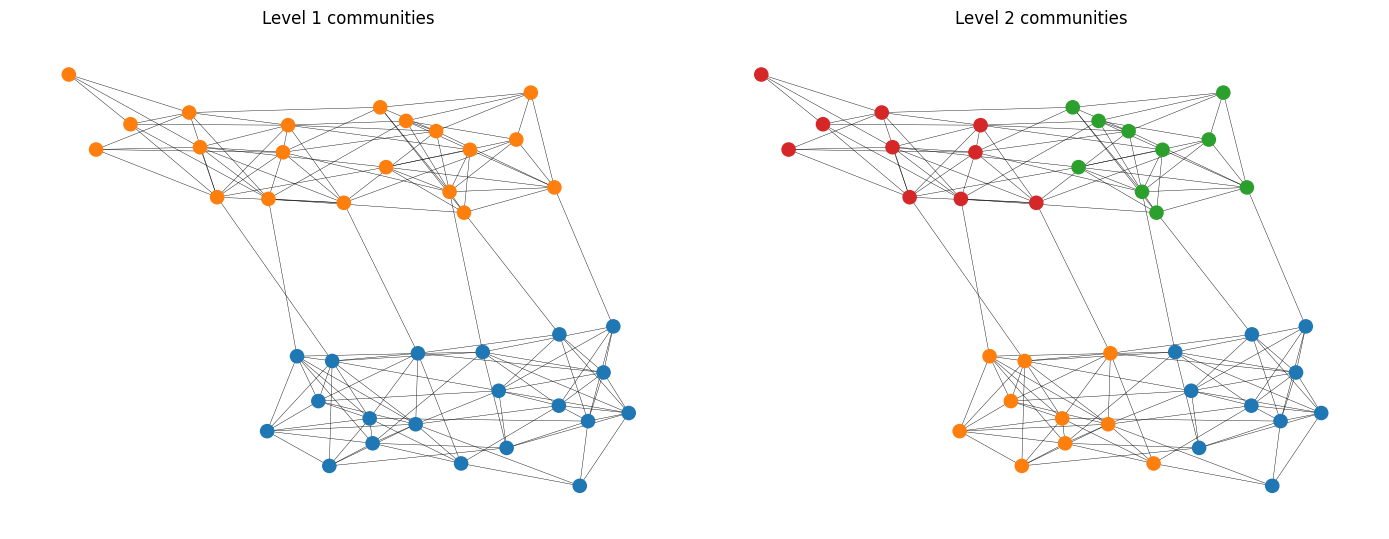

In [ ]:
# ---------------------------------------------------------
# Step 1: A citation graph of 40 papers with a two-level topic structure
# ---------------------------------------------------------
topic_field = {"NLP": "AI / CS", "Vision": "AI / CS", "Genomics": "Biology", "Ecology": "Biology"}
papers = {f"{t}-{i:02d}": t for t in topic_field for i in range(1, 11)}
rng = random.Random(SEED)
research = nx.Graph()
research.add_nodes_from(papers)
names = list(papers)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        same_topic = papers[a] == papers[b]
        same_field = topic_field[papers[a]] == topic_field[papers[b]]
        p = 0.6 if same_topic else (0.12 if same_field else 0.01)
        if rng.random() < p:
            research.add_edge(a, b)
print(f"Research archive: {research.number_of_nodes()} papers, {research.number_of_edges()} citation links")

# ---------------------------------------------------------
# Step 2: Hierarchical Leiden — recurse into each community until it cannot split
# ---------------------------------------------------------
def hierarchical_leiden(G, resolutions, prefix="L0"):
    root = {"id": prefix, "level": 0, "parent": None, "members": sorted(G.nodes()), "is_leaf": False}
    hierarchy, frontier = [root], [root]
    for level, gamma in enumerate(resolutions, start=1):
        next_frontier = []
        for parent in frontier:
            groups = list(groups_of(leiden_partition(G.subgraph(parent["members"]), gamma)).values()) \
                     if len(parent["members"]) > 1 else [parent["members"]]
            if len(groups) == 1:                 # Leiden cannot split it -> it is a leaf
                parent["is_leaf"] = True
                continue
            for j, members in enumerate(sorted(groups, key=len, reverse=True)):
                child = {"id": f"{parent['id']}.{j}", "level": level, "parent": parent["id"],
                         "members": sorted(members), "is_leaf": False}
                hierarchy.append(child)
                next_frontier.append(child)
        frontier = next_frontier
    for c in frontier:                           # deepest level reached -> leaves
        c["is_leaf"] = True
    return hierarchy

def partition_at_level(hierarchy, level):
    """Communities at `level`, plus leaves that stopped splitting higher up."""
    return {c["id"]: c["members"] for c in hierarchy
            if c["level"] == level or (c["is_leaf"] and c["level"] < level)}

research_hierarchy = hierarchical_leiden(research, resolutions=[0.2, 1.0])

# ---------------------------------------------------------
# Step 3: Print the tree, naming each community by its dominant topic/field
# ---------------------------------------------------------
def dominant(members, label_of):
    return Counter(label_of[m] for m in members).most_common(1)[0][0]

for c in research_hierarchy:
    if c["level"] == 0:
        label = "entire research archive"
    elif c["level"] == 1:
        label = dominant(c["members"], {p: topic_field[t] for p, t in papers.items()}) + " papers"
    else:
        label = dominant(c["members"], papers)
    purity = max(Counter(papers[m] for m in c["members"]).values()) / len(c["members"])
    print(f"{'    ' * c['level']}Level {c['level']} [{c['id']}] {label:<24} {len(c['members']):>2} papers"
          + (f"  (topic purity {purity:.0%})" if c["level"] == 2 else "") + ("  <- leaf" if c["is_leaf"] else ""))

for level in (1, 2):
    print(f"Level {level}: ", end="")
    check_partition(research, partition_at_level(research_hierarchy, level))

# ---------------------------------------------------------
# Step 4: Visualise Level 1 and Level 2 side by side
# ---------------------------------------------------------
research_pos = nx.spring_layout(research, seed=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, level in zip(axes, (1, 2)):
    comm_of = {n: i for i, (cid, ms) in enumerate(partition_at_level(research_hierarchy, level).items()) for n in ms}
    nx.draw_networkx(research, research_pos, ax=ax, with_labels=False, node_size=90, width=0.3,
                     node_color=[PALETTE[comm_of[n]] for n in research.nodes()])
    ax.set_title(f"Level {level} communities"); ax.axis("off")
plt.tight_layout(); plt.show()

### Execution Topic 8.6: Hierarchical Leiden on the BMW Knowledge Graph

**What it does:** applies the same hierarchical Leiden to the Q3 knowledge graph. The result is the community tree whose reports we will write in 8.7 and search in Part 10.

**Observe:** Level 1 groups broad operational areas; Level 2 splits them into specific incidents. Leaves are marked.

In [ ]:
# ---------------------------------------------------------
# Hierarchical communities for the Q3 knowledge graph
# ---------------------------------------------------------
bmw_hierarchy = hierarchical_leiden(kg_undirected, resolutions=[0.3, 1.0])
community_by_id = {c["id"]: c for c in bmw_hierarchy}

for c in bmw_hierarchy:
    members = ", ".join(c["members"]) if c["level"] > 0 else f"all {len(c['members'])} entities"
    print(f"{'    ' * c['level']}Level {c['level']} [{c['id']}]{' (leaf)' if c['is_leaf'] else ''}: {members}")

for level in (1, 2):
    print(f"Level {level}: ", end="")
    check_partition(kg_undirected, partition_at_level(bmw_hierarchy, level))

Level 0 [L0]: all 22 entities
    Level 1 [L0.0]: BMW, Customs Hold, Emergency Seals, Hydraulic Oil Leak, Hydraulic Pump Seal Failure, Order #402, Order #447, Press Cell 4, SealTech GmbH
    Level 1 [L0.1]: Nordstahl AG, Nordwerk Motors, Order #415, Port Congestion, Port of Hamburg, Steel Coils, Weld Line 2
    Level 1 [L0.2]: Alpen Trucks, ChemCoat, Order #431, Paint Contamination Defect, Paint Line 1, Primer Batch PB-77
        Level 2 [L0.0.0] (leaf): Customs Hold, Emergency Seals, Hydraulic Oil Leak, Hydraulic Pump Seal Failure, SealTech GmbH
        Level 2 [L0.0.1] (leaf): BMW, Order #402, Order #447, Press Cell 4
        Level 2 [L0.1.0] (leaf): Nordstahl AG, Port Congestion, Port of Hamburg, Steel Coils
        Level 2 [L0.1.1] (leaf): Nordwerk Motors, Order #415, Weld Line 2
        Level 2 [L0.2.0] (leaf): ChemCoat, Primer Batch PB-77
        Level 2 [L0.2.1] (leaf): Paint Contamination Defect, Paint Line 1
        Level 2 [L0.2.2] (leaf): Alpen Trucks, Order #431
Level 1: Mu

### Execution Topic 8.7: Step 5 — Roll Up Community Summaries (bottom-up)

**What it does:** implements slide 25's roll-up:
1. **Leaf communities:** read the community's nodes, edges and claims → write a short community report.
2. **Parent communities:** if all leaf text fits the context budget, summarise it directly; if too long, **replace details with the already-written child reports**.
3. **Repeat** up the hierarchy until Level 0 has a corpus-wide summary.

Reports here are written by a **deterministic template** (`[SIMULATED]`), not an LLM — the point is the bottom-up mechanics and the "fits → raw / too long → child reports" decision.

**Observe:** which path each parent took, and the final Level-0 corpus-wide summary.

In [ ]:
CONTEXT_BUDGET_WORDS = 100   # stand-in for an LLM context window
CAUSE_RELATIONS = {"halted by", "blocked by", "caused by", "delayed by", "delayed by downtime of",
                   "affected by", "delayed at", "waiting for"}

# ---------------------------------------------------------
# Step 1: Raw material of a community = relationships of its entities + dated claims
# ---------------------------------------------------------
def community_facts(members):
    members = set(members)
    facts = []
    for u, v, d in kg.edges(data=True):
        if u in members or v in members:
            for rel, chs in d["relation_chunks"].items():
                facts.append({"fact": f"{u} {rel} {v}", "cause": rel in CAUSE_RELATIONS, "chunks": chs, "weight": len(chs)})
    return facts, claims_df[claims_df.subject.isin(members)]

def raw_text(members):
    facts, claims = community_facts(members)
    return ". ".join([f["fact"] for f in facts] + claims["claim"].tolist())

def headline(facts, n=2):
    causes = sorted((f for f in facts if f["cause"]), key=lambda f: (-f["weight"], f["fact"]))
    return "; ".join(f["fact"] for f in causes[:n]) or "no delay-related findings"

def report_from_raw(members):
    facts, claims = community_facts(members)
    hubs = sorted(members, key=lambda n: kg_undirected.degree(n, weight="weight"), reverse=True)[:3]
    text = (f"Entities: {', '.join(members)}. "
            f"Delay-related findings: {'; '.join(f['fact'] for f in facts if f['cause']) or 'none'}. "
            f"Other relationships: {'; '.join(f['fact'] for f in facts if not f['cause']) or 'none'}. "
            f"Dated claims: {'; '.join(claims['claim']) or 'none'}.")
    return " / ".join(hubs), text

# ---------------------------------------------------------
# Step 2: Walk the hierarchy bottom-up (deepest level first)
# ---------------------------------------------------------
reports = {}
for c in sorted(bmw_hierarchy, key=lambda x: -x["level"]):
    children = [x for x in bmw_hierarchy if x["parent"] == c["id"]]
    raw_words = len(raw_text(c["members"]).split())
    if not children:
        title, text = report_from_raw(c["members"])
        method = "leaf: LLM reads nodes, edges, claims"
    elif raw_words <= CONTEXT_BUDGET_WORDS:
        title, text = report_from_raw(c["members"])
        method = f"parent: all leaf text fits ({raw_words} <= {CONTEXT_BUDGET_WORDS} words) -> summarise directly"
    else:
        title = " + ".join(reports[ch["id"]]["title"].split(" / ")[0] for ch in children)
        text = (f"Built from {len(children)} child reports: "
                + " || ".join(f"{reports[ch['id']]['title']}: {reports[ch['id']]['headline']}" for ch in children))
        method = f"parent: too long ({raw_words} > {CONTEXT_BUDGET_WORDS} words) -> use child reports"
    facts, _ = community_facts(c["members"])
    reports[c["id"]] = {"community_id": c["id"], "level": c["level"], "parent": c["parent"], "is_leaf": c["is_leaf"],
                        "members": c["members"], "title": title, "text": text, "method": method,
                        "headline": headline(facts), "cause_facts": [f for f in facts if f["cause"]],
                        "chunks": sorted({ch for f in facts for ch in f["chunks"]})}

community_reports = pd.DataFrame([reports[c["id"]] for c in bmw_hierarchy])
print(f"[SIMULATED] community reports written: {len(community_reports)} (context budget = {CONTEXT_BUDGET_WORDS} words)")
display(community_reports[["community_id", "level", "is_leaf", "title", "method"]])

leaf_id = next(c["id"] for c in bmw_hierarchy if c["is_leaf"] and "Press Cell 4" in c["members"])
print(f"\n[SIMULATED] Leaf report {leaf_id}:\n  {reports[leaf_id]['text']}")
print("\n[SIMULATED] Level-0 corpus-wide summary:")
for part in reports["L0"]["text"].split(" || "):
    print("  ", part)

[SIMULATED] community reports written: 11 (context budget = 100 words)


,community_id,level,is_leaf,title,method
0,L0,0,False,Emergency Seals + Press Cell 4 + Port of Hamburg + Order #415 + Order #431,parent: too long (393 > 100 words) -> use child reports
1,L0.0,1,False,Emergency Seals + Press Cell 4,parent: too long (174 > 100 words) -> use child reports
2,L0.1,1,False,Port of Hamburg + Order #415,parent: too long (130 > 100 words) -> use child reports
3,L0.2,1,False,Order #431 / Paint Contamination Defect / Alpen Trucks,parent: all leaf text fits (96 <= 100 words) -> summarise directly
4,L0.0.0,2,True,Emergency Seals / Hydraulic Oil Leak / Hydraulic Pump Seal Failure,"leaf: LLM reads nodes, edges, claims"
5,L0.0.1,2,True,Press Cell 4 / BMW / Order #447,"leaf: LLM reads nodes, edges, claims"
6,L0.1.0,2,True,Port of Hamburg / Steel Coils / Nordstahl AG,"leaf: LLM reads nodes, edges, claims"
7,L0.1.1,2,True,Order #415 / Weld Line 2 / Nordwerk Motors,"leaf: LLM reads nodes, edges, claims"
8,L0.2.0,2,True,Primer Batch PB-77 / ChemCoat,"leaf: LLM reads nodes, edges, claims"
9,L0.2.1,2,True,Paint Contamination Defect / Paint Line 1,"leaf: LLM reads nodes, edges, claims"



[SIMULATED] Leaf report L0.0.1:
  Entities: BMW, Order #402, Order #447, Press Cell 4. Delay-related findings: Order #447 delayed by downtime of Press Cell 4; Press Cell 4 halted by Hydraulic Oil Leak; Press Cell 4 halted by Hydraulic Pump Seal Failure. Other relationships: BMW placed Order #402; BMW reported delay on Order #402; BMW placed Order #447; BMW reported delay on Order #447; Order #402 routed to Press Cell 4; Order #447 routed to Press Cell 4. Dated claims: BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2); Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; Press Cell 4 halted again (Sep 3): hydraulic oil leak; BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1); BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).

[SIMULATED] Level-0 corpus-wide summary:
   Built from 3 child reports: Emergency Seals + Press Cell 4: Emerg

## Part 9 — Three Embedding Stores (slides 26–27)

Indexing is complete — we now have **three embedding stores**: Chunks (original text units), Entities (graph nodes + descriptions), Community Reports (theme-level summaries).

### Execution Topic 9.1: Build and Inspect the Three Stores

**What it does:** embeds the entity descriptions and the community reports (chunks were embedded in 1.2), shows what each store holds, and runs one query against each.

**Why it matters:** *Local search uses entities + chunks. Global search uses community reports.*

**Observe:** the same question finds a specific entity in the entity store but a theme-level summary in the report store.

In [ ]:
# ---------------------------------------------------------
# Store 1: Chunks (already embedded in Topic 1.2)
# ---------------------------------------------------------
chunk_store = chunks_df[["chunk_id", "silo", "date", "text"]].copy()

# ---------------------------------------------------------
# Store 2: Entities = graph nodes + aggregated descriptions
# ---------------------------------------------------------
entity_store = pd.DataFrame([{"entity": n, "type": d["type"], "chunks": ", ".join(d["chunks"]), "description": d["description"]}
                             for n, d in kg.nodes(data=True)])
entity_embeddings = embed_model.encode(entity_store["description"].tolist())

# ---------------------------------------------------------
# Store 3: Community reports (all levels except the root)
# ---------------------------------------------------------
report_store = community_reports[community_reports.level > 0][["community_id", "level", "is_leaf", "title", "text", "chunks"]].reset_index(drop=True)
report_embeddings = embed_model.encode(report_store["text"].tolist())

summary = pd.DataFrame([
    {"store": "Chunks",            "rows": len(chunk_store),  "vector dims": chunk_embeddings.shape[1],  "used by": "Local search"},
    {"store": "Entities",          "rows": len(entity_store), "vector dims": entity_embeddings.shape[1], "used by": "Local search"},
    {"store": "Community Reports", "rows": len(report_store), "vector dims": report_embeddings.shape[1], "used by": "Global search"},
])
display(summary)
display(entity_store.head(4))
display(report_store[["community_id", "level", "title"]])

# ---------------------------------------------------------
# One question, three stores
# ---------------------------------------------------------
probe = "Press Cell 4 breakdowns"
print(f"Probe query: '{probe}'")
for name, df, emb, col in [("Chunks", chunk_store, chunk_embeddings, "chunk_id"),
                           ("Entities", entity_store, entity_embeddings, "entity"),
                           ("Community Reports", report_store, report_embeddings, "title")]:
    best = vector_search(probe, k=1, store_df=df, store_embeddings=emb).iloc[0]
    print(f"  best match in {name:<18}: {best[col]}  (sim={best['score']})")

,store,rows,vector dims,used by
0,Chunks,17,384,Local search
1,Entities,22,384,Local search
2,Community Reports,10,384,Global search


,entity,type,chunks,description
0,Alpen Trucks,Customer,"C14, C17",Alpen Trucks (Customer). Alpen Trucks placed/reported delay on Order #431; Alpen Trucks Order #431 cab pai...
1,Order #431,Order,"C14, C17",Order #431 (Order). Alpen Trucks placed/reported delay on Order #431; Order #431 delayed by Paint Contamin...
2,BMW,Customer,"C01, C02, C07, C08",BMW (Customer). BMW placed/reported delay on Order #402; BMW placed/reported delay on Order #447; BMW acco...
3,Order #402,Order,"C01, C02",Order #402 (Order). BMW placed/reported delay on Order #402; Order #402 routed to Press Cell 4


,community_id,level,title
0,L0.0,1,Emergency Seals + Press Cell 4
1,L0.1,1,Port of Hamburg + Order #415
2,L0.2,1,Order #431 / Paint Contamination Defect / Alpen Trucks
3,L0.0.0,2,Emergency Seals / Hydraulic Oil Leak / Hydraulic Pump Seal Failure
4,L0.0.1,2,Press Cell 4 / BMW / Order #447
5,L0.1.0,2,Port of Hamburg / Steel Coils / Nordstahl AG
6,L0.1.1,2,Order #415 / Weld Line 2 / Nordwerk Motors
7,L0.2.0,2,Primer Batch PB-77 / ChemCoat
8,L0.2.1,2,Paint Contamination Defect / Paint Line 1
9,L0.2.2,2,Order #431 / Alpen Trucks


Probe query: 'Press Cell 4 breakdowns'
  best match in Chunks            : C03  (sim=0.576)
  best match in Entities          : Press Cell 4  (sim=0.609)
  best match in Community Reports : Emergency Seals + Press Cell 4  (sim=0.461)


## Part 10 — Query / Retrieval (slides 28–34)

Indexing is done; now the **online** half. Slide 30: **Local** — specific entities (*"Why was Order #402 delayed?"*); **Global** — whole-corpus themes (*"Top causes of delays in Q3?"*).

### Execution Topic 10.1: The Query Router — Local or Global?

**What it does:** a simple, transparent router: if the query names a catalogue entity it goes **Local**; if it asks for corpus-level themes (*top, causes across, pattern, this quarter…*) it goes **Global**; if it needs both, **Hybrid** (slide 33).

This keyword router is an **educational stand-in**, not production-grade — real systems often use an LLM or a trained classifier here.

**Observe:** each test query, the entities and cue words found, and the route chosen.

In [ ]:
# ---------------------------------------------------------
# Router rules: named entity -> LOCAL; theme cue -> GLOBAL; both -> HYBRID
# ---------------------------------------------------------
GLOBAL_CUES = ["top", "main causes", "overall", "themes", "trends", "across", "pattern", "most common",
               "recurring", "this quarter", "q3"]

def route_query(query):
    entities = sorted({m["entity"] for m in find_mentions(query, BMW_CATALOG)})
    cues = [c for c in GLOBAL_CUES if re.search(r"(?<!\w)" + re.escape(c) + r"(?!\w)", query.lower())]
    if entities and cues:
        route = "HYBRID (DRIFT)"
    elif entities:
        route = "LOCAL"
    else:
        route = "GLOBAL"
    return route, entities, cues

test_queries = [
    "Why was Order #402 delayed?",
    "What are the top causes of delays?",
    "Top causes of delays in Q3?",
    "What halted Paint Line 1?",
    "Was Order #402's delay part of a wider pattern on the chassis press line this quarter?",
]
display(pd.DataFrame([dict(zip(["query", "route", "entities found", "theme cues"], (q, *route_query(q))))
                      for q in test_queries]))

,query,route,entities found,theme cues
0,Why was Order #402 delayed?,LOCAL,[Order #402],[]
1,What are the top causes of delays?,GLOBAL,[],[top]
2,Top causes of delays in Q3?,GLOBAL,[],"[top, q3]"
3,What halted Paint Line 1?,LOCAL,[Paint Line 1],[]
4,Was Order #402's delay part of a wider pattern on the chassis press line this quarter?,HYBRID (DRIFT),[Order #402],"[pattern, this quarter]"


### Execution Topic 10.2: Local Search, Step 1 — Entity Search

**What it does:** finds the entry points into the graph for *"Why was Order #402 delayed?"* by (a) exact catalogue match and (b) semantic similarity against the **entity store**.

**Observe:** `Order #402` is the seed entity (the green nodes in slide 31's picture).

In [ ]:
local_query = "Why was Order #402 delayed?"

# ---------------------------------------------------------
# (a) Exact entity mentions in the query
# (b) Semantic nearest entities in the entity store
# ---------------------------------------------------------
exact = sorted({m["entity"] for m in find_mentions(local_query, BMW_CATALOG)})
semantic = vector_search(local_query, k=4, store_df=entity_store, store_embeddings=entity_embeddings)

print(f"Query: {local_query}")
print("Exact entity match :", exact)
print("Semantic matches in the entity store:")
display(semantic[["rank", "entity", "type", "score"]])

seed_entities = exact if exact else semantic["entity"].head(1).tolist()
print("Seed entities for the graph walk:", seed_entities)

Query: Why was Order #402 delayed?
Exact entity match : ['Order #402']
Semantic matches in the entity store:


,rank,entity,type,score
0,1,Order #402,Order,0.669
1,2,Order #447,Order,0.641
2,3,BMW,Customer,0.623
3,4,Order #431,Order,0.569


Seed entities for the graph walk: ['Order #402']


### Execution Topic 10.3: Local Search, Step 2 — k-Hop Neighbourhood

**Mathematical intuition**

$$N_k(v) = \{\,u : d(u, v) \le k\,\}$$

$N_k(v)$ = all entities within $k$ hops of seed $v$, where $d(u,v)$ is the number of edges on the shortest path (direction ignored).

**What it does:** extracts the 1-, 2-, 3- and 4-hop neighbourhoods around `Order #402` and reports what each contains.

**Observe:** k = 2 reaches the pump failure but not the customs hold; k = 4 reaches the whole causal chain; the subgraph grows with every hop (more context, but also more noise — the trade-off from 8.1).

,k,nodes,edges,reaches pump failure,reaches customs hold,new nodes at this hop
0,1,3,2,False,False,"BMW, Press Cell 4"
1,2,6,6,True,False,"Hydraulic Oil Leak, Hydraulic Pump Seal Failure, Order #447"
2,3,7,8,True,False,Emergency Seals
3,4,10,11,True,True,"Customs Hold, Port of Hamburg, SealTech GmbH"


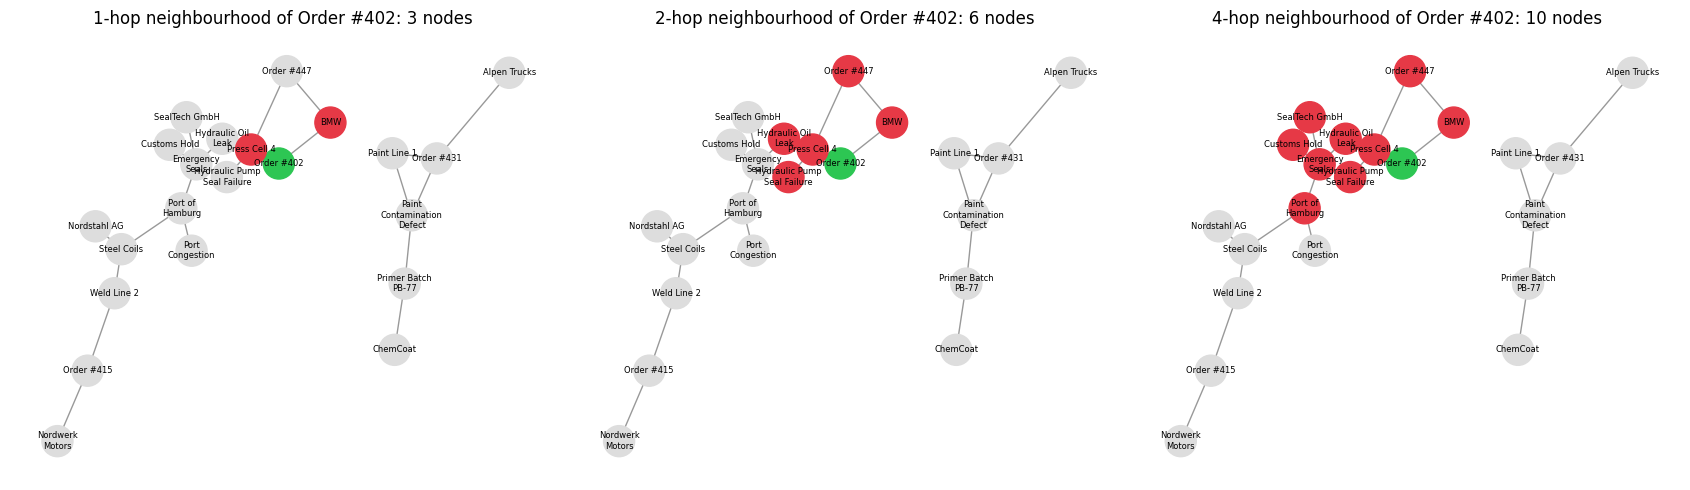

Chosen k = 4: subgraph with 10 nodes, 11 edges


In [ ]:
# ---------------------------------------------------------
# Step 1: How the neighbourhood grows with k
# ---------------------------------------------------------
seed = seed_entities[0]
rows = []
for k in [1, 2, 3, 4]:
    hood = nx.ego_graph(kg_undirected, seed, radius=k)
    rows.append({"k": k, "nodes": hood.number_of_nodes(), "edges": hood.number_of_edges(),
                 "reaches pump failure": "Hydraulic Pump Seal Failure" in hood,
                 "reaches customs hold": "Customs Hold" in hood,
                 "new nodes at this hop": ", ".join(sorted(n for n, d in nx.single_source_shortest_path_length(kg_undirected, seed).items() if d == k))})
display(pd.DataFrame(rows))

# ---------------------------------------------------------
# Step 2: Visualise the growth (seed = green, neighbourhood = red)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, k in zip(axes, [1, 2, 4]):
    hood = set(nx.ego_graph(kg_undirected, seed, radius=k).nodes())
    colors = ["#2dc653" if n == seed else ("#e63946" if n in hood else "#dddddd") for n in kg.nodes()]
    nx.draw_networkx(kg, kg_pos, ax=ax, labels={n: textwrap.fill(n, 14) for n in kg}, node_color=colors,
                     node_size=500, font_size=6, arrows=False, edge_color="#999")
    ax.set_title(f"{k}-hop neighbourhood of {seed}: {len(hood)} nodes"); ax.axis("off")
plt.tight_layout(); plt.show()

K_HOPS = 4
local_subgraph = kg.subgraph(nx.ego_graph(kg_undirected, seed, radius=K_HOPS).nodes()).copy()
print(f"Chosen k = {K_HOPS}: subgraph with {local_subgraph.number_of_nodes()} nodes, {local_subgraph.number_of_edges()} edges")

### Execution Topic 10.4: Local Search, Step 3 — Grounded Text Chunks

**What it does:** maps every candidate node back to the **original text chunks** it was extracted from (its text units — the red dots with documents in slide 31), and ranks chunks by how many subgraph entities they mention.

**Observe:** the maintenance ticket (C03) and the procurement note (C04) — which vector search ranked near the bottom in 4.3 — are now pulled in because they are *connected*, not because they *sound like* the question.

In [ ]:
# ---------------------------------------------------------
# Candidate nodes -> the chunks that mention them (text units)
# ---------------------------------------------------------
hits = mentions_df[mentions_df.entity.isin(local_subgraph.nodes())]
grounded = (hits.groupby("chunk_id")["entity"].agg(lambda s: sorted(set(s))).reset_index()
            .assign(n_entities=lambda d: d["entity"].str.len())
            .merge(chunks_df[["chunk_id", "silo", "text"]], on="chunk_id")
            .sort_values(["n_entities", "chunk_id"], ascending=[False, True]).reset_index(drop=True))
display(grounded[["chunk_id", "silo", "n_entities", "entity", "text"]])
print("Silos represented:", sorted(grounded["silo"].unique()))
print("Contains C03 (root cause) and C04 (blocker):", {"C03", "C04"} <= set(grounded["chunk_id"]))

,chunk_id,silo,n_entities,entity,text
0,C02,Factory Floor Logs,3,"[BMW, Order #402, Press Cell 4]",BMW Order #402 chassis fabrication scheduled on Press Cell 4 (Aug 2).
1,C03,Maintenance Tickets,3,"[Emergency Seals, Hydraulic Pump Seal Failure, Press Cell 4]",Press Cell 4 halted (Aug 10): hydraulic pump seal blowout; repair requires emergency seals.
2,C05,Procurement Invoices,3,"[Emergency Seals, Port of Hamburg, SealTech GmbH]",SealTech GmbH shipped the emergency seals via Port of Hamburg (Aug 6).
3,C06,Maintenance Tickets,3,"[Emergency Seals, Hydraulic Oil Leak, Press Cell 4]",Press Cell 4 halted again (Sep 3): hydraulic oil leak; repair requires emergency seals.
4,C07,Factory Floor Logs,3,"[BMW, Order #447, Press Cell 4]",BMW Order #447 door-panel stamping scheduled on Press Cell 4 (Sep 1).
5,C08,Sales CRM,3,"[BMW, Order #447, Press Cell 4]",BMW account: 10-day delivery delay for Order #447 after Press Cell 4 downtime (Sep 18).
6,C01,Sales CRM,2,"[BMW, Order #402]",BMW account: escalation on 3-week delivery delay for Order #402 (Aug 28); client requested a penalty waiver.
7,C04,Procurement Invoices,2,"[Customs Hold, Emergency Seals]",Emergency seals delayed at port (customs hold).
8,C11,Procurement Invoices,1,[Port of Hamburg],Nordstahl AG shipped steel coils via Port of Hamburg (Jul 5).
9,C12,Procurement Invoices,1,[Port of Hamburg],Steel coils delayed at Port of Hamburg (port congestion) (Jul 8).


Silos represented: ['Factory Floor Logs', 'Maintenance Tickets', 'Procurement Invoices', 'Sales CRM']
Contains C03 (root cause) and C04 (blocker): True


### Execution Topic 10.5: Local Search, Step 4 — Appended Prompt = Serialised Subgraph + Grounded Chunks

**What it does:** serialises the subgraph as triples, appends the top grounded chunks, and prints the final local-search prompt (slide 31: *Prompt = subgraph + grounded chunks*). A deterministic "reader" then follows the directed edges from the seed to show the answer the context supports.

**Observe:** the prompt now contains the full chain from Order #402 to the customs hold, with citations — compare with the Vector RAG answer in 4.2. It also contains a distractor (the **Sep 3** oil leak on the same press); the reader uses the dates carried in the chunks to set it aside.

In [ ]:
MAX_CHUNKS = 6

# ---------------------------------------------------------
# Step 1: Serialise the subgraph as (source, relation, target, weight, evidence) lines
# ---------------------------------------------------------
triples = [f"({u}) -[{'/'.join(d['relations'])}]-> ({v})  weight={d['weight']}  evidence={','.join(d['chunks'])}"
           for u, v, d in local_subgraph.edges(data=True)]
chunk_date = dict(zip(chunks_df.chunk_id, chunks_df.date))
chunk_lines = [f"[{r.chunk_id} | {r.silo} | {chunk_date[r.chunk_id]}] {r.text}" for r in grounded.head(MAX_CHUNKS).itertuples()]

local_prompt = ("Answer using ONLY the knowledge-graph facts and source chunks below. Cite chunk ids.\n\n"
                "Knowledge-graph facts:\n" + "\n".join(triples) +
                "\n\nSource chunks:\n" + "\n".join(chunk_lines) +
                f"\n\nQuestion: {local_query}\nAnswer:")
print(local_prompt)

# ---------------------------------------------------------
# Step 2: [SIMULATED] reader. Like an LLM reading the dates, it only follows
# causal links stated while the order was in progress (first to last date
# of the order's own chunks), then walks the arrows to the root cause(s).
# ---------------------------------------------------------
CHAIN_RELATIONS = CAUSE_RELATIONS | {"routed to", "requires"}

def timely_causal_graph(G, window):
    H = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        for rel, chs in d["relation_chunks"].items():
            if rel in CHAIN_RELATIONS and any(window[0] <= chunk_date[c] <= window[1] for c in chs):
                H.add_edge(u, v, relation=rel, chunks=chs)
    return H

seed_dates = sorted(chunk_date[c] for c in kg.nodes[seed]["chunks"])
window = (seed_dates[0], seed_dates[-1])
timely = timely_causal_graph(local_subgraph, window)
print(f"\n[SIMULATED] reader - {seed} was in progress {window[0]} .. {window[1]}")
for u, v, d in local_subgraph.edges(data=True):
    for rel, chs in d["relation_chunks"].items():
        if rel in CHAIN_RELATIONS and not timely.has_edge(u, v):
            print(f"  set aside: {u} {rel} {v} ({', '.join(f'{c} {chunk_date[c]}' for c in chs)}) - outside that window")
roots = [n for n in nx.descendants(timely, seed) if timely.out_degree(n) == 0]
for root in roots:
    chain = nx.shortest_path(timely, seed, root)
    print("  Answer chain: " + seed + "".join(f" -[{timely.edges[u, v]['relation']}, {','.join(timely.edges[u, v]['chunks'])}]-> {v}"
                                             for u, v in zip(chain, chain[1:])))

Answer using ONLY the knowledge-graph facts and source chunks below. Cite chunk ids.

Knowledge-graph facts:
(Emergency Seals) -[blocked by]-> (Customs Hold)  weight=1  evidence=C04
(Emergency Seals) -[shipped via]-> (Port of Hamburg)  weight=1  evidence=C05
(Hydraulic Oil Leak) -[requires]-> (Emergency Seals)  weight=1  evidence=C06
(Hydraulic Pump Seal Failure) -[requires]-> (Emergency Seals)  weight=1  evidence=C03
(SealTech GmbH) -[supplies]-> (Emergency Seals)  weight=1  evidence=C05
(Order #447) -[delayed by downtime of/routed to]-> (Press Cell 4)  weight=2  evidence=C07,C08
(Press Cell 4) -[halted by]-> (Hydraulic Oil Leak)  weight=1  evidence=C06
(Press Cell 4) -[halted by]-> (Hydraulic Pump Seal Failure)  weight=1  evidence=C03
(Order #402) -[routed to]-> (Press Cell 4)  weight=1  evidence=C02
(BMW) -[placed/reported delay on]-> (Order #402)  weight=2  evidence=C01,C02
(BMW) -[placed/reported delay on]-> (Order #447)  weight=2  evidence=C07,C08

Source chunks:
[C02 | Factory F

### Execution Topic 10.6: Global Search, Steps 1–2 — Community Search, Take Top-k Reports

**Mathematical intuition:** rank every community report $r$ by $\cos(q, r)$ and keep the top-$k$ — the same top-k rule as 1.4, but over **theme-level summaries** instead of chunks.

**What it does:** starts slide 32's right-hand path for *"What were the top causes of delivery delays in Q3?"* by searching the community-report store.

**Observe:** the top-k reports come from different parts of the graph — each one a different theme.

In [ ]:
TOP_K_REPORTS = 8

# ---------------------------------------------------------
# Community search over the report store
# ---------------------------------------------------------
def community_search(query, k=TOP_K_REPORTS):
    return vector_search(query, k=k, store_df=report_store, store_embeddings=report_embeddings)

candidates = community_search(global_question)
print(f"Query: {global_question}\nTop-{TOP_K_REPORTS} community reports:")
display(candidates[["rank", "community_id", "level", "title", "score"]])

Query: What were the top causes of delivery delays in Q3?
Top-8 community reports:


,rank,community_id,level,title,score
0,1,L0.0.1,2,Press Cell 4 / BMW / Order #447,0.420
1,2,L0.1.0,2,Port of Hamburg / Steel Coils / Nordstahl AG,0.402
2,3,L0.0,1,Emergency Seals + Press Cell 4,0.360
3,4,L0.1.1,2,Order #415 / Weld Line 2 / Nordwerk Motors,0.354
4,5,L0.0.0,2,Emergency Seals / Hydraulic Oil Leak / Hydraulic Pump Seal Failure,0.346
5,6,L0.2.2,2,Order #431 / Alpen Trucks,0.342
6,7,L0.1,1,Port of Hamburg + Order #415,0.307
7,8,L0.2.1,2,Paint Contamination Defect / Paint Line 1,0.303


### Execution Topic 10.7: Global Search, Step 3 — MAP: Each Report → Intermediate Answer + Score

**What it does:** the **Map** step (slide 32): every candidate report is sent to the LLM *independently*, which returns an intermediate answer and a relevance score (0–100). Our `[SIMULATED]` map function answers with the report's delay-related findings and scores relevance as 100 × cosine(query, report).

**Observe:** one intermediate answer per report, each with its score and evidence chunks.

In [ ]:
# ---------------------------------------------------------
# [SIMULATED] map step: report -> (intermediate answer, relevance score 0-100)
# ---------------------------------------------------------
def map_step(query, candidates):
    rows = []
    for r in candidates.itertuples():
        rep = reports[r.community_id]
        answer_points = [f["fact"] for f in rep["cause_facts"]]
        rows.append({"community_id": r.community_id, "level": r.level, "title": r.title,
                     "score": int(round(100 * r.score)),
                     "intermediate_answer": "; ".join(answer_points) if answer_points else "(no relevant facts)",
                     "points": answer_points, "evidence": rep["chunks"]})
    return pd.DataFrame(rows)

mapped = map_step(global_question, candidates)
print("[SIMULATED] MAP output:")
display(mapped[["community_id", "level", "score", "intermediate_answer"]])

[SIMULATED] MAP output:


,community_id,level,score,intermediate_answer
0,L0.0.1,2,42,Order #447 delayed by downtime of Press Cell 4; Press Cell 4 halted by Hydraulic Oil Leak; Press Cell 4 ha...
1,L0.1.0,2,40,Port of Hamburg affected by Port Congestion; Steel Coils delayed at Port of Hamburg; Weld Line 2 waiting f...
2,L0.0,1,36,Order #447 delayed by downtime of Press Cell 4; Emergency Seals blocked by Customs Hold; Press Cell 4 halt...
3,L0.1.1,2,35,Order #415 delayed by downtime of Weld Line 2; Weld Line 2 waiting for Steel Coils
4,L0.0.0,2,35,Emergency Seals blocked by Customs Hold; Press Cell 4 halted by Hydraulic Oil Leak; Press Cell 4 halted by...
5,L0.2.2,2,34,Order #431 delayed by Paint Contamination Defect
6,L0.1,1,31,Port of Hamburg affected by Port Congestion; Steel Coils delayed at Port of Hamburg; Order #415 delayed by...
7,L0.2.1,2,30,Order #431 delayed by Paint Contamination Defect; Paint Contamination Defect caused by Primer Batch PB-77;...


### Execution Topic 10.8: Global Search, Step 4 — FILTER: Drop Weak Scores

**Mathematical intuition:** keep report $r$ only if $\text{score}(r) \ge \tau$ (and it produced at least one relevant point).

**What it does:** applies a score-based filter with threshold $\tau$.

**Observe:** which intermediate answers survive and which are dropped (and why).

In [ ]:
SCORE_THRESHOLD = 33   # tau

def filter_step(mapped, tau=SCORE_THRESHOLD):
    keep = (mapped["score"] >= tau) & (mapped["points"].str.len() > 0)
    return mapped[keep].reset_index(drop=True), mapped[~keep].reset_index(drop=True)

kept, dropped = filter_step(mapped)
print(f"Threshold tau = {SCORE_THRESHOLD}  ->  kept {len(kept)}, dropped {len(dropped)}")
print("\nKept:");    display(kept[["community_id", "score", "intermediate_answer"]])
print("Dropped:");   display(dropped[["community_id", "score", "intermediate_answer"]])

Threshold tau = 33  ->  kept 6, dropped 2

Kept:


,community_id,score,intermediate_answer
0,L0.0.1,42,Order #447 delayed by downtime of Press Cell 4; Press Cell 4 halted by Hydraulic Oil Leak; Press Cell 4 ha...
1,L0.1.0,40,Port of Hamburg affected by Port Congestion; Steel Coils delayed at Port of Hamburg; Weld Line 2 waiting f...
2,L0.0,36,Order #447 delayed by downtime of Press Cell 4; Emergency Seals blocked by Customs Hold; Press Cell 4 halt...
3,L0.1.1,35,Order #415 delayed by downtime of Weld Line 2; Weld Line 2 waiting for Steel Coils
4,L0.0.0,35,Emergency Seals blocked by Customs Hold; Press Cell 4 halted by Hydraulic Oil Leak; Press Cell 4 halted by...
5,L0.2.2,34,Order #431 delayed by Paint Contamination Defect


Dropped:


,community_id,score,intermediate_answer
0,L0.1,31,Port of Hamburg affected by Port Congestion; Steel Coils delayed at Port of Hamburg; Order #415 delayed by...
1,L0.2.1,30,Order #431 delayed by Paint Contamination Defect; Paint Contamination Defect caused by Primer Batch PB-77;...


### Execution Topic 10.9: Global Search, Step 5 — REDUCE: Aggregate, Deduplicate, Rank → Final Answer

**What it does:** the **Reduce** step: pools all surviving intermediate points (**aggregate**), merges points that several reports repeated — a parent and its child often overlap (**deduplicate**), then orders them by how many community answers support each point, breaking ties by the best map score (**rank**).

**Observe:** a ranked list of Q3 delay causes spanning all silos, each with evidence chunks — and how many duplicates were removed.

In [ ]:
# ---------------------------------------------------------
# Reduce: aggregate -> deduplicate -> rank
# ---------------------------------------------------------
def reduce_step(kept):
    pooled = [(p, r.score, r.community_id) for r in kept.itertuples() for p in r.points]   # aggregate
    merged = {}
    for point, score, cid in pooled:                                                          # deduplicate
        m = merged.setdefault(point, {"point": point, "support": 0, "best_score": 0, "communities": []})
        m["support"] += 1
        m["best_score"] = max(m["best_score"], score)
        m["communities"].append(cid)
    fact_meta = {f["fact"]: f for rep in reports.values() for f in rep["cause_facts"]}
    ranked = sorted(merged.values(), key=lambda x: (-x["support"], -x["best_score"], x["point"]))  # rank
    for x in ranked:
        x["evidence"] = ",".join(fact_meta[x["point"]]["chunks"])
    return pooled, pd.DataFrame(ranked)

pooled, final_points = reduce_step(kept)
print(f"Aggregated points: {len(pooled)} -> after deduplication: {len(final_points)} "
      f"({len(pooled) - len(final_points)} duplicates removed)\n")

display(final_points[["point", "support", "best_score", "communities", "evidence"]])
global_answer = "Top causes of delivery delays in Q3 (ranked by how many community answers support them):\n" + "\n".join(
    f"{i}. {r.point}  [evidence {r.evidence}]" for i, r in enumerate(final_points.itertuples(), 1))
print("[SIMULATED] final global answer:\n" + global_answer)

cov = causes_covered([global_answer])
print(f"\nRoot causes covered: {sum(cov.values())} of {len(cov)}  (vector RAG top-4 in Topic 4.5 covered "
      f"{sum(causes_covered(vector_search(global_question, k=4)['text']).values())})")

Aggregated points: 16 -> after deduplication: 9 (7 duplicates removed)



,point,support,best_score,communities,evidence
0,Press Cell 4 halted by Hydraulic Oil Leak,3,42,"[L0.0.1, L0.0, L0.0.0]",C06
1,Press Cell 4 halted by Hydraulic Pump Seal Failure,3,42,"[L0.0.1, L0.0, L0.0.0]",C03
2,Order #447 delayed by downtime of Press Cell 4,2,42,"[L0.0.1, L0.0]",C08
3,Weld Line 2 waiting for Steel Coils,2,40,"[L0.1.0, L0.1.1]",C13
4,Emergency Seals blocked by Customs Hold,2,36,"[L0.0, L0.0.0]",C04
5,Port of Hamburg affected by Port Congestion,1,40,[L0.1.0],C12
6,Steel Coils delayed at Port of Hamburg,1,40,[L0.1.0],C12
7,Order #415 delayed by downtime of Weld Line 2,1,35,[L0.1.1],C09
8,Order #431 delayed by Paint Contamination Defect,1,34,[L0.2.2],C17


[SIMULATED] final global answer:
Top causes of delivery delays in Q3 (ranked by how many community answers support them):
1. Press Cell 4 halted by Hydraulic Oil Leak  [evidence C06]
2. Press Cell 4 halted by Hydraulic Pump Seal Failure  [evidence C03]
3. Order #447 delayed by downtime of Press Cell 4  [evidence C08]
4. Weld Line 2 waiting for Steel Coils  [evidence C13]
5. Emergency Seals blocked by Customs Hold  [evidence C04]
6. Port of Hamburg affected by Port Congestion  [evidence C12]
7. Steel Coils delayed at Port of Hamburg  [evidence C12]
8. Order #415 delayed by downtime of Weld Line 2  [evidence C09]
9. Order #431 delayed by Paint Contamination Defect  [evidence C17]

Root causes covered: 4 of 4  (vector RAG top-4 in Topic 4.5 covered 2)


### Execution Topic 10.10: What If We Need Both? — DRIFT Hybrid Querying (slides 33–34)

**DRIFT** = Dynamic Reasoning and Inference with Flexible Traversal:
* **Primer:** top-k community reports (global theme)
* **Refine:** local neighbourhood search (specifics)
* **Iterate:** follow-ups for broader, deeper answers

**What it does:** answers slide 33's question — *"Was Order #402's delay part of a wider pattern on the chassis press line this quarter?"* — with a primer from the report store, a local refinement around Order #402, and one follow-up question generated from what the refinement found.

**Observe:** neither mode alone answers it; together they show Press Cell 4 halted twice in Q3 and delayed two BMW orders.

In [ ]:
drift_query = "Was Order #402's delay part of a wider pattern on the chassis press line this quarter?"
print("Route:", route_query(drift_query)[0], "\n")

# ---------------------------------------------------------
# Step 1: PRIMER — global theme from the top-2 community reports
# ---------------------------------------------------------
primer = community_search(drift_query, k=2)
print("PRIMER (global):")
for r in primer.itertuples():
    print(f"  [{r.community_id}] {r.title} (sim={r.score}) -> {reports[r.community_id]['headline']}")

# ---------------------------------------------------------
# Step 2: REFINE — local 2-hop neighbourhood of the entity named in the query
# ---------------------------------------------------------
drift_seed = route_query(drift_query)[1][0]
refine = kg.subgraph(nx.ego_graph(kg_undirected, drift_seed, radius=2).nodes())
machine = next(v for u, v, d in kg.out_edges(drift_seed, data=True) if "routed to" in d["relations"])
print(f"\nREFINE (local around {drift_seed}): {refine.number_of_nodes()} nodes; it was routed to {machine}")

# ---------------------------------------------------------
# Step 3: ITERATE — follow-up question generated from the refinement
# ---------------------------------------------------------
follow_up = f"Which orders were routed to {machine} in Q3, and what halted {machine}?"
orders_on_machine = sorted(u for u, _, d in kg.in_edges(machine, data=True) if kg.nodes[u]["type"] == "Order")
failures = sorted((v for _, v, d in kg.out_edges(machine, data=True) if "halted by" in d["relations"]),
                  key=lambda f: min(chunk_date[c] for c in kg.edges[machine, f]["chunks"]))
failure_dates = {f: claims_df[claims_df.chunk_id.isin(kg.edges[machine, f]["chunks"])]["time"].tolist() for f in failures}
print(f"\nITERATE follow-up: {follow_up}")
print("  Orders routed there:", orders_on_machine)
print("  Failures that halted it:", {f: failure_dates[f] for f in failures})

print("\n[SIMULATED] DRIFT answer:")
print(f"  Yes. {machine} was halted {len(failures)} times this quarter "
      f"({'; '.join(f'{f} on {d[0]}' for f, d in failure_dates.items())}), "
      f"delaying {len(orders_on_machine)} BMW orders ({', '.join(orders_on_machine)}). "
      f"Both repairs depended on emergency seals.")

Route: HYBRID (DRIFT) 

PRIMER (global):
  [L0.0.1] Press Cell 4 / BMW / Order #447 (sim=0.518) -> Order #447 delayed by downtime of Press Cell 4; Press Cell 4 halted by Hydraulic Oil Leak
  [L0.2.2] Order #431 / Alpen Trucks (sim=0.468) -> Order #431 delayed by Paint Contamination Defect

REFINE (local around Order #402): 6 nodes; it was routed to Press Cell 4

ITERATE follow-up: Which orders were routed to Press Cell 4 in Q3, and what halted Press Cell 4?
  Orders routed there: ['Order #402', 'Order #447']
  Failures that halted it: {'Hydraulic Pump Seal Failure': ['Aug 10'], 'Hydraulic Oil Leak': ['Sep 3']}

[SIMULATED] DRIFT answer:
  Yes. Press Cell 4 was halted 2 times this quarter (Hydraulic Pump Seal Failure on Aug 10; Hydraulic Oil Leak on Sep 3), delaying 2 BMW orders (Order #402, Order #447). Both repairs depended on emergency seals.


## Part 11 — Evaluation and Adoption (slides 35–37)

### Execution Topic 11.1: Evaluating Global Sensemaking — Head-to-Head, LLM-as-a-Judge

Slide 36: there are **no gold answers**, so an LLM judge compares two systems head-to-head and picks a **winner (or tie) per criterion**:
* **Comprehensiveness** — covers all aspects of the question?
* **Diversity** — varied perspectives and insights?
* **Empowerment** — helps the reader judge the topic?
* **Directness** (control) — clear, specific, concise?

**What it does:** a `[SIMULATED]` judge with transparent proxy rules stands in for the LLM: aspects covered (comprehensiveness), distinct silos cited (diversity), distinct evidence citations (empowerment), word count — fewer is better (directness). Win rate = wins ÷ comparisons.

**Observe:** Graph RAG wins comprehensiveness, diversity and empowerment; Vector RAG wins **directness** — the trade-off slide 36 calls out.

In [ ]:
# ---------------------------------------------------------
# Step 1: Two systems' answers for two global questions
# ---------------------------------------------------------
def vector_rag_answer(q, k=4):
    hits = vector_search(q, k=k)
    return " ".join(f"{r.text} [{r.chunk_id}]" for r in hits.itertuples())

def graph_rag_answer(q):
    kept_, _ = filter_step(map_step(q, community_search(q)))
    _, pts = reduce_step(kept_)
    return " ".join(f"{r.point} [{r.evidence}]." for r in pts.itertuples())

eval_questions = [global_question, "Which recurring problems affected customer orders across the plant this quarter?"]

# ---------------------------------------------------------
# Step 2: [SIMULATED] judge — proxy score per criterion (higher is better)
# ---------------------------------------------------------
silo_of = dict(zip(chunks_df.chunk_id, chunks_df.silo))
def cited(ans): return set(re.findall(r"C\d{2}", ans))
CRITERIA = {
    "Comprehensiveness": lambda a: sum(causes_covered([a]).values()),
    "Diversity":         lambda a: len({silo_of[c] for c in cited(a)}),
    "Empowerment":       lambda a: len(cited(a)),
    "Directness":        lambda a: -len(a.split()),      # shorter = more direct
}

rows = []
for q in eval_questions:
    a_vec, a_graph = vector_rag_answer(q), graph_rag_answer(q)
    for crit, fn in CRITERIA.items():
        s_vec, s_graph = fn(a_vec), fn(a_graph)
        winner = "Graph RAG" if s_graph > s_vec else ("Vector RAG" if s_vec > s_graph else "Tie")
        rows.append({"question": q[:45] + "...", "criterion": crit, "vector": abs(s_vec), "graph": abs(s_graph), "winner": winner})
verdicts = pd.DataFrame(rows)
display(verdicts)

# ---------------------------------------------------------
# Step 3: Win rate per criterion = wins / comparisons
# ---------------------------------------------------------
win_rate = (verdicts.assign(graph_win=verdicts.winner.eq("Graph RAG"), vector_win=verdicts.winner.eq("Vector RAG"))
            .groupby("criterion")[["graph_win", "vector_win"]].mean().mul(100).round(0))
win_rate.columns = ["Graph RAG win %", "Vector RAG win %"]
display(win_rate)

,question,criterion,vector,graph,winner
0,What were the top causes of delivery delays i...,Comprehensiveness,2,4,Graph RAG
1,What were the top causes of delivery delays i...,Diversity,2,4,Graph RAG
2,What were the top causes of delivery delays i...,Empowerment,4,8,Graph RAG
3,What were the top causes of delivery delays i...,Directness,54,78,Vector RAG
4,Which recurring problems affected customer or...,Comprehensiveness,2,3,Graph RAG
5,Which recurring problems affected customer or...,Diversity,3,3,Tie
6,Which recurring problems affected customer or...,Empowerment,4,6,Graph RAG
7,Which recurring problems affected customer or...,Directness,57,62,Vector RAG


,Graph RAG win %,Vector RAG win %
criterion,,
Comprehensiveness,100.0,0.0
Directness,0.0,100.0
Diversity,50.0,0.0
Empowerment,100.0,0.0


### Execution Topic 11.2: Why Isn't Graph RAG Everywhere Yet? — Indexing Is Expensive

**What it does:** counts the work each index actually required **in this notebook** — model calls, not money.

**Observe:** vector RAG needed only embedding calls; Graph RAG added one extraction call per chunk and one summary call per community report, on top of three embedding stores.

In [ ]:
# ---------------------------------------------------------
# Actual counts from this notebook's pipeline
# ---------------------------------------------------------
n_reports = len(community_reports)
index_work = pd.DataFrame([
    {"step": "Embed chunks",                    "vector RAG": len(chunks_df), "graph RAG": len(chunks_df), "call type": "embedding"},
    {"step": "Extract entities/relations",      "vector RAG": 0, "graph RAG": len(chunks_df), "call type": "LLM"},
    {"step": "Write community reports",         "vector RAG": 0, "graph RAG": n_reports, "call type": "LLM"},
    {"step": "Embed entities",                  "vector RAG": 0, "graph RAG": len(entity_store), "call type": "embedding"},
    {"step": "Embed community reports",         "vector RAG": 0, "graph RAG": len(report_store), "call type": "embedding"},
])
display(index_work)
llm_calls = index_work.loc[index_work["call type"] == "LLM", ["vector RAG", "graph RAG"]].sum()
emb_calls = index_work.loc[index_work["call type"] == "embedding", ["vector RAG", "graph RAG"]].sum()
print(f"LLM calls       : vector = {llm_calls['vector RAG']}, graph = {llm_calls['graph RAG']}")
print(f"Embedding calls : vector = {emb_calls['vector RAG']}, graph = {emb_calls['graph RAG']}")
print("An LLM call is far more expensive than an embedding call — that gap is the indexing bill.")

,step,vector RAG,graph RAG,call type
0,Embed chunks,17,17,embedding
1,Extract entities/relations,0,17,LLM
2,Write community reports,0,11,LLM
3,Embed entities,0,22,embedding
4,Embed community reports,0,10,embedding


LLM calls       : vector = 0, graph = 28
Embedding calls : vector = 17, graph = 49
An LLM call is far more expensive than an embedding call — that gap is the indexing bill.


### Execution Topic 11.3: Hard to Keep Fresh — One New Document

**What it does:** a new maintenance ticket arrives. Vector RAG: embed one chunk, done. Graph RAG: extract it, merge it into the graph (edge weights change), re-run community detection, and find which community reports must be **regenerated** (the changed leaf and every ancestor up to Level 0).

**Observe:** the list of work items Graph RAG triggers for a single document.

In [ ]:
new_doc = ("C18", "Maintenance Tickets", "2026-09-24",
           "Press Cell 4 halted (Sep 24): hydraulic pump seal blowout; repair requires emergency seals.")

# ---------------------------------------------------------
# Vector RAG update: one embedding
# ---------------------------------------------------------
print("Vector RAG update: embed 1 chunk ->", embed_model.encode([new_doc[3]]).shape)

# ---------------------------------------------------------
# Graph RAG update: extract -> merge -> re-detect -> re-summarise
# ---------------------------------------------------------
_, new_rels, _ = extract_graph_elements(new_doc[3], new_doc[0], BMW_CATALOG, BMW_SCHEMA)
kg_updated = merge_to_graph(pd.concat([raw_relations_df, pd.DataFrame(new_rels)], ignore_index=True))
print(f"\nGraph RAG update: 1 extraction call -> {len(new_rels)} relations")
for u, v in [(r["source"], r["target"]) for r in new_rels]:
    print(f"  weight {u} -> {v}: {kg.edges[u, v]['weight']} -> {kg_updated.edges[u, v]['weight']}")

new_partition = leiden_partition(kg_updated.to_undirected())
same = all((bmw_partition[a] == bmw_partition[b]) == (new_partition[a] == new_partition[b]) for a in kg for b in kg)
print("Community assignments unchanged after re-running Leiden:", same)

touched = {n for r in new_rels for n in (r["source"], r["target"])}
leaves_hit = [c["id"] for c in bmw_hierarchy if c["is_leaf"] and touched & set(c["members"])]
to_regen = set()
for cid in leaves_hit:
    while cid:
        to_regen.add(cid)
        cid = community_by_id[cid]["parent"]
print("Community reports to regenerate (leaf -> root):", sorted(to_regen))
print(f"Work items: vector = 1 embedding | graph = 1 LLM extraction + community re-detection + "
      f"{len(to_regen)} LLM summaries + {len(to_regen) + len(touched)} re-embeddings")

Vector RAG update: embed 1 chunk -> (1, 384)

Graph RAG update: 1 extraction call -> 2 relations
  weight Press Cell 4 -> Hydraulic Pump Seal Failure: 1 -> 2
  weight Hydraulic Pump Seal Failure -> Emergency Seals: 1 -> 2
Community assignments unchanged after re-running Leiden: True
Community reports to regenerate (leaf -> root): ['L0', 'L0.0', 'L0.0.0', 'L0.0.1']
Work items: vector = 1 embedding | graph = 1 LLM extraction + community re-detection + 4 LLM summaries + 7 re-embeddings


### Execution Topic 11.4: Ops Complexity — Entity Quality

**What it does:** simulates what happens when extraction writes the same machine two ways — *"Press Cell 4"* in some chunks and *"Press Cell #4"* in others — and no one normalises the names.

**Observe:** the graph splits, the causal path from Order #402 to the customs hold **disappears**, and normalising the entity name restores it. Entity quality is an operational job, not a one-off.

In [ ]:
# ---------------------------------------------------------
# Simulate an extraction inconsistency on the maintenance/procurement side
# ---------------------------------------------------------
messy = raw_relations_df.copy()
inconsistent_chunks = ["C03", "C06"]
messy.loc[messy.chunk_id.isin(inconsistent_chunks) & (messy.source == "Press Cell 4"), "source"] = "Press Cell #4"
messy_graph = merge_to_graph(messy)

print("Nodes naming the press cell:", [n for n in messy_graph if "Press Cell" in n])
try:
    nx.shortest_path(timely_causal_graph(messy_graph, window), "Order #402", "Customs Hold")
    print("Path found")
except nx.NetworkXNoPath:
    print("Order #402 -> Customs Hold: NO PATH (graph split by a duplicate entity)")

# ---------------------------------------------------------
# Fix: normalise names to the canonical entity, then rebuild
# ---------------------------------------------------------
ALIASES = {"Press Cell #4": "Press Cell 4"}
fixed = messy.replace({"source": ALIASES, "target": ALIASES})
fixed_graph = merge_to_graph(fixed)
print("After normalisation:", " -> ".join(nx.shortest_path(timely_causal_graph(fixed_graph, window), "Order #402", "Customs Hold")))

Nodes naming the press cell: ['Press Cell 4', 'Press Cell #4']
Order #402 -> Customs Hold: NO PATH (graph split by a duplicate entity)
After normalisation: Order #402 -> Press Cell 4 -> Hydraulic Pump Seal Failure -> Emergency Seals -> Customs Hold


### Execution Topic 11.5: Often Overkill — Vector RAG by Default, Graph RAG When It Pays

**What it does:** checks that plain vector RAG already answers simple **local lookup** questions (top-1 hit), then applies slide 37's *typical pattern*: vector RAG by default; Graph RAG for high-value **multi-hop** or **global-synthesis** questions.

**Observe:** 4/4 lookups answered by vector RAG alone; only the "why" and theme questions get escalated to Graph RAG.

In [ ]:
# ---------------------------------------------------------
# Step 1: Simple lookups — does vector RAG's top-1 hit the right chunk?
# ---------------------------------------------------------
lookups = [("Which press cell was Order #402 scheduled on?", "C02"),
           ("Who supplied primer batch PB-77?", "C16"),
           ("What was Weld Line 2 waiting for?", "C13"),
           ("Which port handled the steel coils from Nordstahl AG?", "C11")]
rows = [{"question": q, "expected": exp, "top-1": vector_search(q, k=1).loc[0, "chunk_id"]} for q, exp in lookups]
lookup_df = pd.DataFrame(rows).assign(correct=lambda d: d["expected"] == d["top-1"])
display(lookup_df)
print(f"Vector RAG top-1 accuracy on local lookups: {lookup_df.correct.sum()}/{len(lookup_df)}")

# ---------------------------------------------------------
# Step 2: Slide 37's typical pattern as a routing policy
# ---------------------------------------------------------
MULTI_HOP_CUES = ["why", "cause", "root", "because", "led to"]
def choose_system(q):
    route, _, cues = route_query(q)
    if cues:
        return "Graph RAG (global synthesis)"
    if any(re.search(rf"\b{c}\b", q.lower()) for c in MULTI_HOP_CUES):
        return "Graph RAG (multi-hop local)"
    return "Vector RAG (default)"

policy = [q for q, _ in lookups] + [executive_question, global_question]
display(pd.DataFrame({"question": policy, "system": [choose_system(q) for q in policy]}))

,question,expected,top-1,correct
0,Which press cell was Order #402 scheduled on?,C02,C02,True
1,Who supplied primer batch PB-77?,C16,C16,True
2,What was Weld Line 2 waiting for?,C13,C13,True
3,Which port handled the steel coils from Nordstahl AG?,C11,C11,True


Vector RAG top-1 accuracy on local lookups: 4/4


,question,system
0,Which press cell was Order #402 scheduled on?,Vector RAG (default)
1,Who supplied primer batch PB-77?,Vector RAG (default)
2,What was Weld Line 2 waiting for?,Vector RAG (default)
3,Which port handled the steel coils from Nordstahl AG?,Vector RAG (default)
4,Why was the custom BMW chassis order delayed by three weeks in August?,Graph RAG (multi-hop local)
5,What were the top causes of delivery delays in Q3?,Graph RAG (global synthesis)


## Wrap-up — We Have the Full Architecture (slide 35)

**Indexing** (chunks → extraction → knowledge graph → hierarchical Leiden communities → roll-up reports → three embedding stores) **+ Retrieval** (router → Local / Global / DRIFT).

### Slide → execution map

| Slides | Topic | Execution topics |
|---|---|---|
| 3–4 | Vector RAG pipeline | 1.1 – 1.5 |
| 5 | What RAG solved: cutoff, private data, hallucination, provenance | 2.1 – 2.3 |
| 6–7 | BMW case, four silos, executive question | 3.1 |
| 8 | Why standard vector RAG fails (Sim. table, only A retrieved, global theme) | 4.1 – 4.3, 4.5 |
| 9–10 | Multi-hop breakdown, isolated islands | 4.4 |
| 11–12 | Nodes, edges, causal chain | 5.1 – 5.3 |
| 13 | Better odds with a graph; indexing offline | 5.4, 6.2 |
| 14–16, 28–29 | Architecture: offline indexing vs online retrieval | 6.1 |
| 17–18 | Indexing pipeline; documents → chunks; chunk-size trade-off | 7.1 |
| 19 | Extract entities, relations, claims (NeoChip) | 7.2, 7.3 |
| 20 | Build KG; merge; edge weight = 7 | 7.4, 7.5 |
| 21 | Graph is huge | 8.1 |
| 22 | What is a community | 8.2, 8.4 |
| 23 | Hierarchical communities (research archive) | 8.5, 8.6 |
| 24 | Leiden, run hierarchically; exclusive + exhaustive | 8.3 – 8.6 |
| 25 | Roll-up community summaries | 8.7 |
| 26–27 | Three embedding stores | 9.1 |
| 30 | Two query modes + router | 10.1 |
| 31 | Local search: entity search, k-hop, grounded chunks | 10.2 – 10.5 |
| 32 | Global search: top-k, Map, Filter, Reduce | 10.6 – 10.9 |
| 33–34 | Hybrid / DRIFT | 10.10 |
| 36 | Evaluation: LLM-as-a-judge criteria | 11.1 |
| 37 | Adoption: cost, freshness, ops, overkill, typical pattern | 11.2 – 11.5 |

### References (slide 38)
1. Edge et al. *From Local to Global: A Graph RAG Approach to Query-Focused Summarization.* arXiv:2404.16130, 2024.
2. Traag, Waltman and van Eck. *From Louvain to Leiden: guaranteeing well-connected communities.* Scientific Reports, 2019.
3. Pelin Balci. *Understanding the Leiden Algorithm.* Medium.
4. Microsoft Research. *GraphRAG documentation (Local, Global, and DRIFT search).*
5. Microsoft Data Science. *GraphRAG beyond the demo: lessons from the trenches.*